<a href="https://colab.research.google.com/github/Julianpucheta/OptimalControl/blob/main/Approximated_Policy/Ejemplos_Control_Extrapolacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control automático con aproximaciones de funciones

Se realizan aproximaciones de la ley de control y del funcional de costo, requiriendo generalizaciones para interpolación y para extrapolación.

## Control óptimo para procesos no lineales

Programación dinámica numérica.

## Programación dinámica regresiva

### Índice
No cuadrático. Ejemplo de una variable de estado.

$J=\sum_{k=0}^4(2+u_{(k)})e^{-x_{(k)}}  +|x_{(5)}-1|$

In [1]:
import numpy as np

def indice(k, x, accion):
    y = (2 + accion) * np.exp(-x)
    return y

### Modelo
$x_{(k+1)}=x_{(k)}+[2-2x_{(k)}+\frac{5}{4}x_{(k)}^2-\frac{1}{4}x_{(k)}^3 ]u_{(k)}$

In [2]:
def mopdm(k, xant, accion):
    y = xant + (2 - 2 * xant + (5/4) * xant**2 - (1/4) * xant**3) * accion
    return y

Algoritmo.

In [ ]:
!pip install SciencePlots # !pip install git+https://github.com/garrettj403/SciencePlots

In [4]:
# from PIL import Image
# import scipy.io as sio
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
import scienceplots
import time

In [ ]:
# Parameters
alfa = 50
Nmax = 3 * alfa
Mmax = 3 * alfa
etapas = 6
xmin, xmax = 0, 3
umin, umax = -1, 1
# Initialization
dx = Nmax
du = Mmax
x1 = np.zeros(dx)
x = np.linspace(xmin, xmax, Nmax)
u = np.linspace(umin, umax, Mmax)
xmuno = -10 * np.ones((etapas, dx))
uopt = 1e3 * np.ones((etapas, dx))
costomin = 1e7 * np.ones((etapas, dx))
# Initial cost at final stage
for ii in range(dx):
    costomin[etapas - 1, ii] = abs(x[ii] - 1)
# Backward dynamic programming
start_time = time.time()
x2 = np.zeros(dx)
for k in range(etapas - 2, -1, -1):
    for posi_x in range(dx):
        for i in range(du):
            xy = mopdm(k, x[posi_x], u[i])
            ele = indice(k, x[posi_x], u[i])
            lugar = np.argmin(np.abs(x - xy))
            x2[lugar] = 1
            JJ = costomin[k + 1, lugar] + ele
            if JJ < costomin[k, posi_x]:
                costomin[k, posi_x] = JJ
                uopt[k, posi_x] = u[i]
TCalculo = time.time() - start_time
# Forward simulation for 4 initial conditions
costo = np.zeros((4, etapas))
estado = np.zeros((4, etapas))
u_opt = np.zeros((4, etapas))
for CI in range(4):
    inx = CI
    estado[CI, 0] = inx
    for k in range(etapas - 1):
        lugar = np.argmin(np.abs(x - inx))
        an = uopt[k, lugar]
        u_opt[CI, k] = an
        costo[CI, k + 1] = indice(k, inx, an) + costo[CI, k]
        inx = mopdm(k, inx, an)
        estado[CI, k + 1] = inx
    costo[CI, etapas - 1] += abs(inx - 1)
# Output calculation time
print('Tiempo de cálculo:',TCalculo)

Tiempo de cálculo: 1.0623202323913574


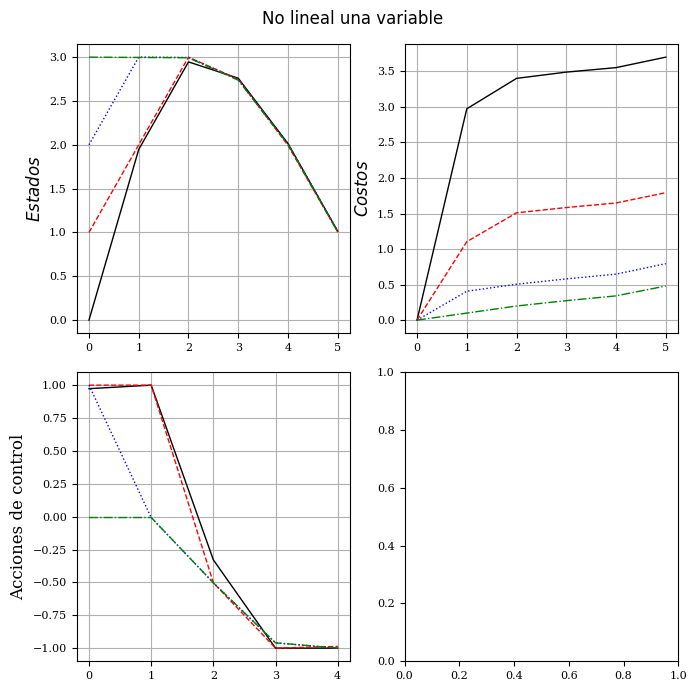

In [ ]:
# Gráficos
xx = np.arange(etapas)
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'No lineal una variable')
axs[0,0].plot(xx, estado.T, linewidth =1.0)
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
axs[0,1].plot(xx, costo.T, linewidth =1.0)
axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
axs[0,1].grid( True )
axs[1,0].plot(xx[:-1], u_opt[:, :-1].T, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
plt.tight_layout()
plt.show()

In [ ]:
# Plotting
xx = np.arange(etapas)
fig = make_subplots(rows=2, cols=2, subplot_titles=("Estados", "Costo", "Ley μ tabulada"))

for i in range(4):
    fig.add_trace(go.Scatter(x=xx, y=estado[i], mode='lines+markers', name=f'Estado {i}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=xx, y=costo[i], mode='lines+markers', name=f'Costo {i}'), row=1, col=2)
    fig.add_trace(go.Scatter(x=xx[:etapas-1], y=u_opt[i, :etapas-1], mode='lines+markers', name=f'u_opt {i}'), row=2, col=1)

fig.update_xaxes(title_text="Etapas", row=2, col=1)
fig.update_yaxes(title_text="Acciones de control", row=2, col=1)
fig.update_yaxes(title_text="Estados", row=1, col=1)
fig.update_yaxes(title_text="Costos", row=1, col=2)
fig.update_layout(title_text="Resultados del Modelo Discreto", height=700)
fig.show()

# # Save the plot
# fig.write_image("modelo_discreto_resultados.png")
# fig.write_json("modelo_discreto_resultados.json")
# fig.show()

## Aprendizaje Q: basado en PD con $\mu(x)$ tabulada

### Ley de control

Algoritmo búsqueda en tabla (Look Up Table, LUT).

In [ ]:
def pol_tab_mu1(entrada, M_est, Ya):
#     """
#     Da la acción de control correspondiente a la entrada.
#     Parámetros:
#     entrada : lista o array con dos elementos [ix1, ix2]
#     M_est   : matriz numpy con forma (3, n) donde las filas son [k(:), ix1(:), ix2(:)]
#     Ya      : array con las acciones de control
#     Retorna:
#     u : acción de control correspondiente
#     """
#     # Calcula la distancia ponderada
    distancias = np.abs((entrada[0] - M_est[0, :]) / 6.) + np.abs((entrada[1] - M_est[1, :]) / 3.)
    inx = np.argmin(distancias)
    return Ya[inx]

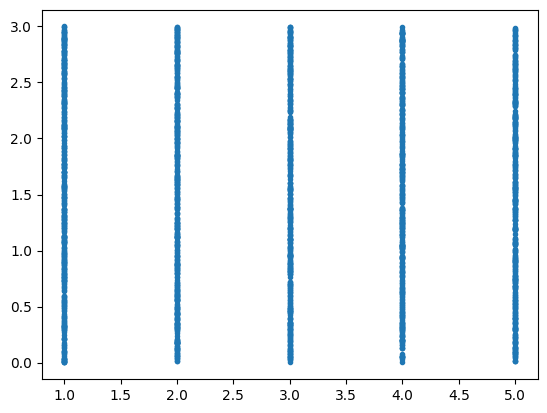

In [ ]:
plt.plot(M_est[0,:],M_est[1,:],'.')

In [ ]:
# Parámetros
TM = 2000
Mmax = 15
etapas = 6
xmin, xmax = 0., 3.
umin, umax = -1., 1.
CI = 2.
vfinal = 1.
# Inicialización
start_time = time.time()
np.random.seed(0)
equis1 = 3 * np.random.rand(TM)
tiempo = np.ceil((etapas - 1) * np.random.rand(TM))
M_est = np.vstack((tiempo, equis1))
Au = (umax - umin) / (Mmax - 1)
uf = np.array([umin + Au * i for i in range(Mmax)])
Q = np.zeros((TM, Mmax))
J = np.zeros(TM)
Ya = np.zeros(TM)
m = np.zeros((TM, Mmax))
Q11 = np.zeros(15)
Q12 = np.zeros(15)
# Simulación inicial
sal = [CI]
costo = [0]
for k in range(etapas - 1):
    entrada = [k+1, sal[k]]
    consigna = pol_tab_mu1(entrada, M_est, Ya)
    sal.append(mopdm(k, sal[k], consigna))
    costo.append(costo[k] + indice(k, sal[k], consigna))
costo[-1] += np.abs(sal[-1] - vfinal)
Max0=np.max(M_est[0, :])
Max1=np.max(M_est[1, :])
# Aprendizaje Q
evoluc = [] # Initialize as an empty list
for iterac in range(15):
    for iq in range(TM):
        k = int(M_est[0, iq])
        x = M_est[1, iq]
        for acc in range(Mmax):
            xy = mopdm(k, x, uf[acc])
            m[iq, acc] += 1
            gama = 0.10 * m[iq, acc] / (1.0 + 0.10 * m[iq, acc])
            if k < etapas - 1:
                lugar = np.argmin(np.abs(((k + 1) - M_est[0, :]) / Max0) +
                                  np.abs((xy - M_est[1, :]) / Max1))
                Q[iq, acc] = (1 - gama) * Q[iq, acc] + gama * (indice(k, x, uf[acc]) + J[lugar])
            else:
                Q[iq, acc] = (1 - gama) * Q[iq, acc] + gama * (indice(k, x, uf[acc]) + np.abs(xy - vfinal))
    for iq in range(TM):
        lugar = np.argmin(Q[iq, :])
        J[iq] = Q[iq, lugar]
        Ya[iq] = uf[lugar]
    Q11[iterac]=Q[0,0]
    Q12[iterac]=Q[10,3]
    # Evaluation
    sal = [CI]
    costo = [0]
    for k in range(etapas - 1):
        entrada = [k+1, sal[k]]
        consigna = pol_tab_mu1(entrada, M_est, Ya)
        sal.append(mopdm(k, sal[k], consigna))
        costo.append(costo[k] + indice(k, sal[k], consigna))
    costo[-1] += np.abs(sal[-1] - vfinal)
    evoluc.append(costo[-1]) # Append to the list
    print(f"Costo final: {evoluc[iterac]}", f"Iteración: {iterac}")
# Convert the list to a numpy array after the loop
evoluc = np.array(evoluc)
TCalculo = time.time() - start_time
print('Tiempo de cálculo:',TCalculo)

Costo final: 7939530.939703091 Iteración: 0
Costo final: 7939530.939703091 Iteración: 1
Costo final: 7939530.939703091 Iteración: 2
Costo final: 79023.8587870433 Iteración: 3
Costo final: 200.32427048075948 Iteración: 4
Costo final: 0.9100741136780385 Iteración: 5
Costo final: 0.8388044500809564 Iteración: 6
Costo final: 0.826941146345564 Iteración: 7
Costo final: 0.826941146345564 Iteración: 8
Costo final: 0.8035502594805151 Iteración: 9
Costo final: 0.8035502594805151 Iteración: 10
Costo final: 0.8035502594805151 Iteración: 11
Costo final: 0.8035502594805151 Iteración: 12
Costo final: 0.8035502594805151 Iteración: 13
Costo final: 0.8035502594805151 Iteración: 14
Tiempo de cálculo: 12.202396869659424


Cálculo para cada una de las condiciones iniciales

In [ ]:
costo_tab = np.zeros((4, etapas))
estado_tab = np.zeros((4, etapas))
u_opt_tab = np.zeros((4, etapas))
for CI_idx in range(4):
    inx = CI_idx
    estado_tab[CI_idx, 0] = inx
    for k in range(etapas - 1):
        entrada = [k+1, inx]
        an = pol_tab_mu1(entrada, M_est, Ya)
        u_opt_tab[CI_idx, k] = an
        costo_tab[CI_idx, k + 1] = indice(k, inx, an) + costo_tab[CI_idx, k]
        inx = mopdm(k, inx, an)
        estado_tab[CI_idx, k + 1] = inx
    costo_tab[CI_idx, -1] += np.abs(inx - 1)

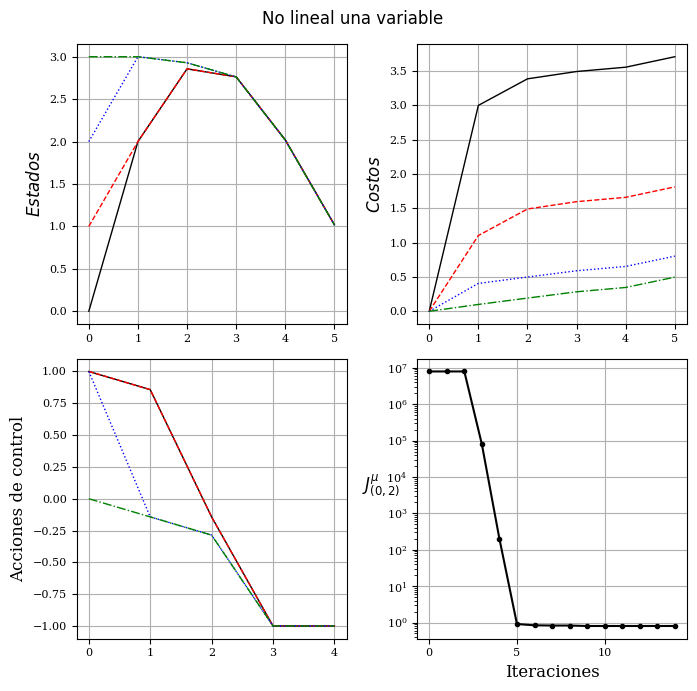

In [ ]:
# Gráficos
xx = np.arange(etapas)
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'No lineal una variable')
axs[0,0].plot(xx, estado_tab.T, linewidth =1.0)
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
axs[0,1].plot(xx, costo_tab.T, linewidth =1.0)
axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
axs[0,1].grid( True )
axs[1,0].plot(xx[:-1], u_opt_tab[:, :-1].T, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
axs[1,1].semilogy(evoluc, '.-')
axs[1,1].set_ylabel(r'$J^{\mu}_{(0,2)}$',rotation=0, fontsize=12)
axs[1,1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1,1].grid( True )
plt.tight_layout()
plt.show()

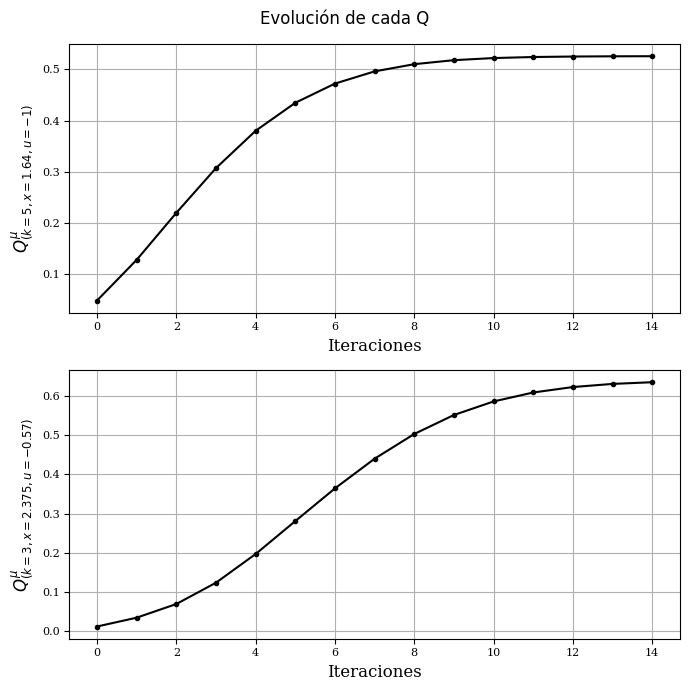

In [ ]:
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de cada Q')
axs[0].plot(Q11, '.-')
axs[0].set_ylabel(r'$Q^{\mu}_{(k=5, x=1.64,u=-1)}$',rotation=90, fontsize=12)
axs[0].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(Q12, '.-')
axs[1].set_ylabel(r'$Q^{\mu}_{(k=3, x=2.375,u=-0.57)}$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

## Programación dinámica con aproximaciones

Rutina que aproxima funciones a partir de conjuntos de datos.
Por ejemplo, se disponen de datos como muestra la figura, donde z es la imagen y {x,y} es el dominio de la función.

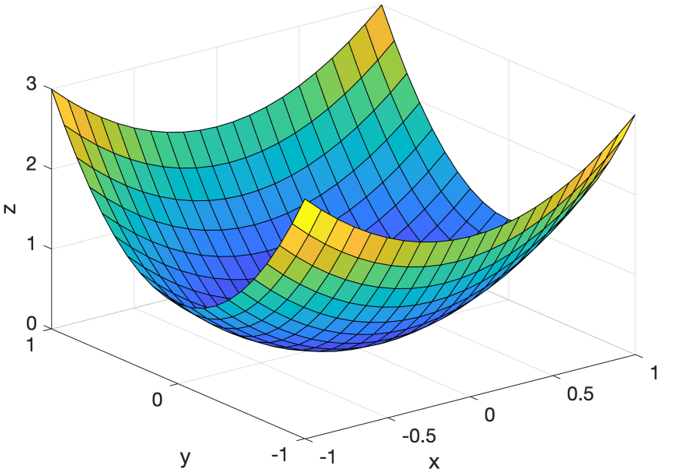

### Programación dinámica aproximada. Aproximación de $J(x,u)$ con $\mu(x)$ tabulada.

In [ ]:
def pol_tab_mu1(entrada, M_est, Ya):
#     """
#     Da la acción de control correspondiente a la entrada.
#     Parámetros:
#     entrada : lista o array con dos elementos [ix1, ix2]
#     M_est   : matriz numpy con forma (3, n) donde las filas son [k(:), ix1(:), ix2(:)]
#     Ya      : array con las acciones de control
#     Retorna:
#     u : acción de control correspondiente
#     """
#     # Calcula la distancia ponderada
    distancias = np.abs((entrada[0] - M_est[0, :]) / 4.) + np.abs((entrada[1] - M_est[1, :]) / 3.)
    inx = np.argmin(distancias)
    return Ya[inx]

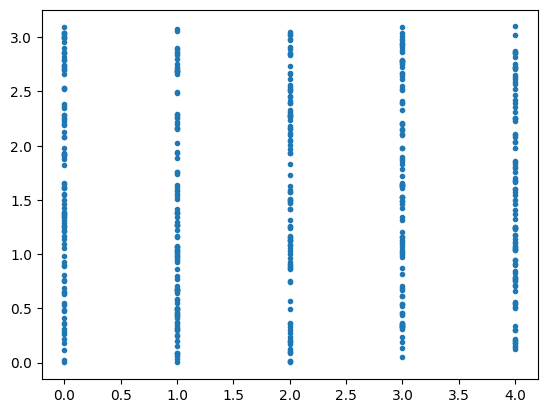

In [ ]:
plt.plot(M_est[0,:],M_est[1,:],'.')

In [ ]:
from sklearn.neural_network import MLPRegressor
# Set random seed for reproducibility
np.random.seed(0)
# Parameters (translated from MATLAB)
alpha = 4
Nmax = 4 * alpha
Mmax = 5 * alpha
etapas = 6  # Number of stages
xmin = 0
xmax = 3
umin = -1
umax = 1
# Inicialización
start_time = time.time()
TM = 500
CI = 2.  # Initial condition
vfinal = 1.  # Final state target
# Generate control inputs (uf)
Au = (umax - umin) / (Mmax - 1)
uf = np.array([umin + Au * (i - 1) for i in range(1, Mmax + 1)])
# Generate random data for M_est
tiempo = np.ceil((etapas - 1) * np.random.rand(TM)).astype(int)-np.ones(TM)
equis1 = 3.1 * np.random.rand(TM)
M_est = np.vstack((tiempo, equis1))  # [time; state]
Ho = 5 #Neuronas ocultas
mlp_1 = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.2, activation='tanh', solver='lbfgs',
                   max_iter=1000,  random_state=0)
# Initialize data structures
Q = np.zeros((TM, len(uf)))
J = np.zeros(TM)
Ya = np.zeros(TM)
sal = np.zeros(etapas)
costo = np.zeros(etapas)
sal[0] = CI
costo[0] = 0
M_It=25 #Número de iteraciones
gama =np.zeros(M_It+1)
gama[0] = 0.1
Q11 =np.zeros(M_It)
Q12 =np.zeros(M_It)
evoluc=np.zeros(M_It)
Yo = np.zeros(TM)
PHI = M_est.copy()
# Main iteration loop
for iterac in range(M_It):
    # Compute costs for each sample in M_est
    for iq in range(TM):
        Jc = 0
        kini = int(M_est[0, iq])
        x = M_est[1, iq]
        PHI[0,iq]=kini
        PHI[1,iq]=x
        for k in range(kini, etapas - 1):
            entrada = np.array([k, x])
            u = pol_tab_mu1(entrada, M_est, Ya)
            xy = mopdm(k, x, u)
            if xmin <= xy <= xmax:  # Check constraints
                if k < etapas - 2:
                    Jc += indice(k, x, u)
                    x = xy
                else:
                    Jc += indice(k, x, u) + abs(xy - vfinal)
            else:
                if xy > xmax:
                    Jc += 5 * abs(xmax - xy)
                if xy < xmin:
                    Jc += 5 * abs(xy - xmin)
                break
        Yo[iq] = Jc
    # Train neural network
    X_train = PHI.T  # bias term
    if iterac>0:
      mlp_1.coefs_ = pesos_guardados
      mlp_1.intercepts_ = bias_guardados
    mlp_1.fit(X_train, Yo)
    # Guardar los pesos
    pesos_guardados = mlp_1.coefs_.copy()
    bias_guardados = mlp_1.intercepts_.copy()
    # Compute Q-values
    for iq in range(TM):
        k = int(M_est[0, iq]) #k empieza en cero.
        x = M_est[1, iq]
        for acc in range(len(uf)):
            xy = mopdm(k, x, uf[acc])
            entrada = np.array([[k+1, xy]])
            y2 = mlp_1.predict(entrada)[0]
            y2 = max(0, y2)  # ReLU-like behavior
            if k  < etapas - 2:
                Q[iq, acc] = indice(k, x, uf[acc]) + gama[iterac] * y2
            else:
                Q[iq, acc] = indice(k, x, uf[acc]) +   abs(xy - vfinal)
    # Update policy
    for iq in range(TM):
        val = np.min(Q[iq, :])
        lugar = np.argmin(Q[iq, :])
        J[iq] = val
        Ya[iq] = uf[lugar]
    gama[iterac+1]=(5 * (iterac+1) / (5 + 5 * (1+iterac)))  # Update gamma
    Q11[iterac]=Q[49,0]
    Q12[iterac]=Q[10,3]
    # Evaluate policy
    sal[0] = CI
    costo = np.zeros(etapas)
    for k in range(etapas - 1):
        entrada = np.array([k, sal[k]])
        consigna = pol_tab_mu1(entrada, M_est, Ya)
        sal[k + 1] = mopdm(k, sal[k], consigna)
        costo[k + 1] = costo[k] + indice(k, sal[k], consigna)
    costo[etapas - 1] += abs(sal[etapas - 1] - vfinal)
    evoluc[iterac]=costo[etapas - 1]
    print(f"Costo final: {evoluc[iterac]}", f"Iteración: {iterac}")
TCalculo = time.time() - start_time
print('Tiempo de cálculo:',TCalculo)

Costo final: 41.529767283986814 Iteración: 0
Costo final: 1.7076635261821576 Iteración: 1


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html



Costo final: 1.7140111603227828 Iteración: 2
Costo final: 1.2195044379216458 Iteración: 3


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html



Costo final: 0.9580275733994208 Iteración: 4
Costo final: 0.9710138765534952 Iteración: 5
Costo final: 0.9497718742060319 Iteración: 6
Costo final: 1.0078423057501649 Iteración: 7
Costo final: 1.0272145192640707 Iteración: 8
Costo final: 0.9497718742060319 Iteración: 9
Costo final: 0.9633686224536989 Iteración: 10
Costo final: 1.0314967658754777 Iteración: 11
Costo final: 1.0172373103942516 Iteración: 12
Costo final: 0.9748132194795728 Iteración: 13
Costo final: 1.0078423057501649 Iteración: 14
Costo final: 0.9718698666208385 Iteración: 15
Costo final: 1.0193099676213175 Iteración: 16
Costo final: 1.0193099676213175 Iteración: 17
Costo final: 1.0193099676213175 Iteración: 18
Costo final: 1.0193099676213175 Iteración: 19
Costo final: 1.0193099676213175 Iteración: 20
Costo final: 1.0193099676213175 Iteración: 21
Costo final: 0.9547379644638929 Iteración: 22
Costo final: 1.0193099676213175 Iteración: 23
Costo final: 0.9547379644638929 Iteración: 24
Tiempo de cálculo: 42.617345333099365


Tiempo de cálculo: 42.617345333099365


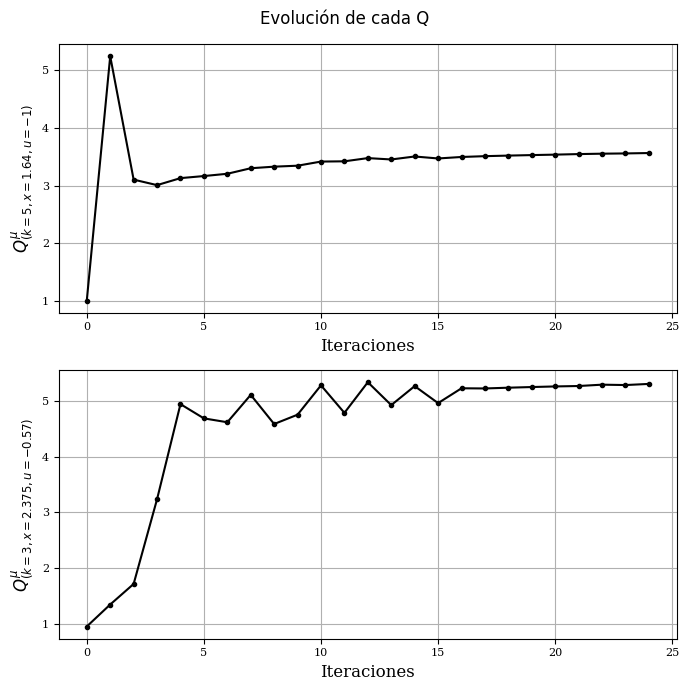

In [ ]:
print('Tiempo de cálculo:',TCalculo)
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de cada Q')
axs[0].plot(Q11, '.-')
axs[0].set_ylabel(r'$Q^{\mu}_{(k=5, x=1.64,u=-1)}$',rotation=90, fontsize=12)
axs[0].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(Q12, '.-')
axs[1].set_ylabel(r'$Q^{\mu}_{(k=3, x=2.375,u=-0.57)}$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

In [ ]:
estado_tab=np.array(np.zeros((4,etapas)))
costo_tab=np.array(np.zeros((4,etapas)))
u_opt_tab=np.array(np.zeros((4,etapas-1)))
for CI_idx in range(4):
    inx = CI_idx
    estado_tab[CI_idx, 0] = inx
    for k in range(etapas - 1):
        entrada = [k, inx]
        an = pol_tab_mu1(entrada, M_est, Ya)
        u_opt_tab[CI_idx, k] = an
        costo_tab[CI_idx, k + 1] = indice(k, inx, an) + costo_tab[CI_idx, k]
        inx = mopdm(k, inx, an)
        estado_tab[CI_idx, k + 1] = inx
    costo_tab[CI_idx, -1] += np.abs(inx - 1)

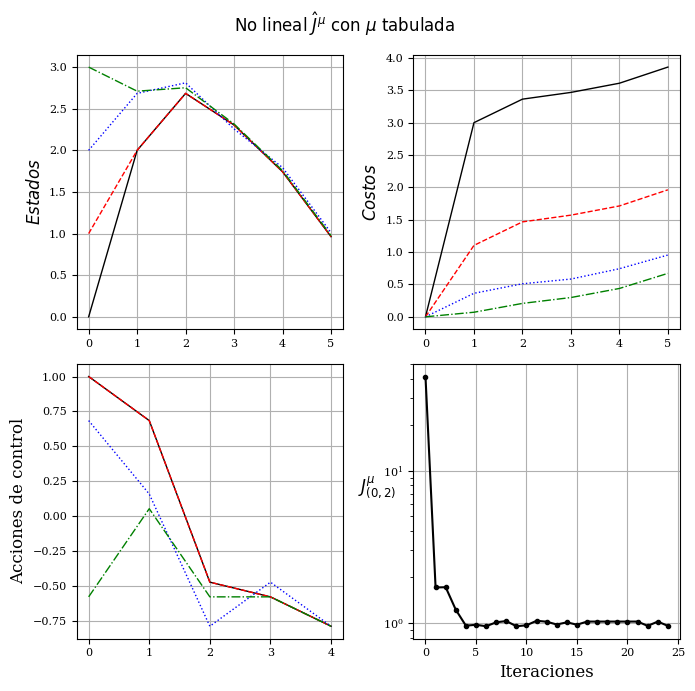

In [ ]:
# Gráficos
xx = np.arange(etapas)
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'No lineal $\hat{J}^{\mu}$ con $\mu$ tabulada')
axs[0,0].plot(xx, estado_tab.T, linewidth =1.0)
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
axs[0,1].plot(xx, costo_tab.T, linewidth =1.0)
axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
axs[0,1].grid( True )
axs[1,0].plot(xx[:-1], u_opt_tab[:, :].T, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
axs[1,1].semilogy(evoluc, '.-')
axs[1,1].set_ylabel(r'$J^{\mu}_{(0,2)}$',rotation=0, fontsize=12)
axs[1,1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1,1].grid( True )
plt.tight_layout()
plt.show()

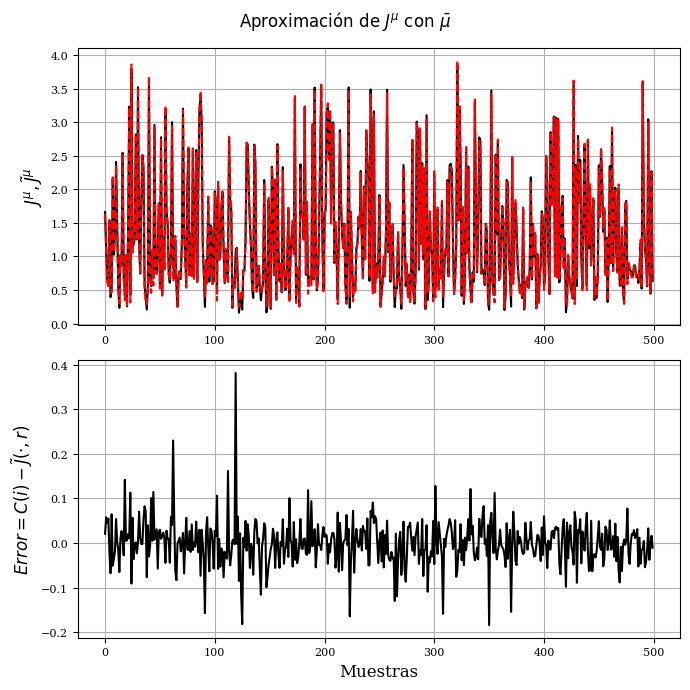

In [ ]:
Yo_ap=np.zeros(len(Yo))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Yo_ap[k1] = mlp_1.predict(entrada.reshape(1, -1))[0]
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de $J^{\mu}$ con $\bar{\mu}$')
axs[0].plot(Yo)
axs[0].plot(Yo_ap)
axs[0].set_ylabel(r'$J^{\mu},\tilde{J}^{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Yo-Yo_ap)
axs[1].set_ylabel(r'$Error=C(i)-\tilde{J}(\cdot,r)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

### PD con aproximación de $J(x,u)$ y de $\mu(x)$

[link text](https://)Programación dinámica aproximada. Aproximación de $J(x,u)$ y $\mu()$.

In [54]:
# Generate random data for M_est
tiempo = np.ceil((etapas-1) * np.random.rand(TM)).astype(int)-np.ones(TM)
equis1 = 3.1 * np.random.rand(TM)
M_est = np.vstack((tiempo, equis1))  # [time; state]

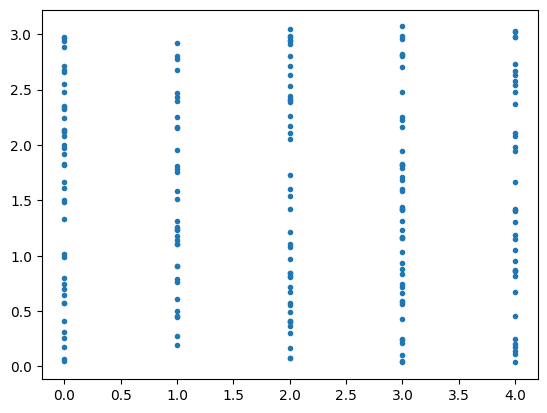

In [ ]:
plt.plot(M_est[0,:],M_est[1,:],'.')


In [ ]:
from sklearn.neural_network import MLPRegressor
# Set random seed for reproducibility
np.random.seed(0)
alpha = 4
Nmax = 4 * alpha
Mmax = 5 * alpha
etapas = 6  # Number of stages
xmin = 0
xmax = 3
umin = -1
umax = 1
# Inicialización
start_time = time.time()
TM = 300
CI = 2.  # Initial condition
vfinal = 1.  # Final state target
# Generate control inputs (uf)
Au = (umax - umin) / (Mmax - 1)
uf = np.array([umin + Au * (i - 1) for i in range(1, Mmax + 1)])
# Generate random data for M_est
tiempo = np.ceil((etapas - 1) * np.random.rand(TM)).astype(int)-np.ones(TM)
equis1 = 3.1 * np.random.rand(TM)
M_est = np.vstack((tiempo, equis1))  # [time; state]
Ho = 10 #Neuronas ocultas
mlp_J = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.2, activation='tanh', solver='lbfgs',
                   max_iter=1000,  random_state=0)
mlp_a = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.2, activation='tanh', solver='lbfgs',
                   max_iter=1000,  random_state=0)
# Initialize data structures
Q = np.zeros((TM, len(uf)))
J = np.zeros(TM) #Ya = np.zeros(TM)
Ya= np.random.randn(TM)
sal = np.zeros(etapas)
costo = np.zeros(etapas)
sal[0] = CI
costo[0] = 0
M_It = 100 #-------------------------Número de iteraciones-------------------------
gama =np.zeros(M_It+1)
gama[0] = 0.1
Q11 =np.zeros(M_It)
Q12 =np.zeros(M_It)
evoluc=np.zeros(M_It)
Yo = np.zeros(TM)
PHI = M_est.copy()
X_train = PHI.T  #
mlp_a.fit(X_train, Ya) #ajusta primer ley de control aleatoria
# Main iteration loop
for iterac in range(M_It):
    # Compute costs for each sample in M_est
    for iq in range(TM):
        Jc = np.zeros(etapas)
        kini = int(M_est[0, iq])
        x = M_est[1, iq]
        for k in range(kini, etapas - 1):
            entrada = np.array([[k, x]]) # u = pol_tab_mu1(entrada, M_est, Ya)
            u = mlp_a.predict(entrada)[0]
            xy = mopdm(k, x, u)
            if xmin <= xy <= xmax:  # Check constraints
                if k < etapas - 2:
                    Jc[k] = indice(k, x, u)
                    x = xy
                else:
                    Jc[k] = indice(k, x, u) + abs(xy - vfinal) # print("Entró Jc=", Jc)
            else:
                if xy > xmax:
                    Jc[k] = 5 * abs(xmax - xy)
                if xy < xmin:
                    Jc[k] = 5 * abs(xy - xmin)
                break
        Yo[iq]=0
        for k in range(etapas,0,-1):
          Yo[iq] = Jc[k-1]+gama[iterac]*Yo[iq]
        # Yo[iq] = Jc
    # Train neural network     # X_train = PHI.T  # bias term
    if iterac>0:
      mlp_J.coefs_ = pesos_guardados_J
      mlp_J.intercepts_ = bias_guardados_J
    mlp_J.fit(X_train, Yo)
    # Guardar los pesos
    pesos_guardados_J = mlp_J.coefs_.copy()
    bias_guardados_J = mlp_J.intercepts_.copy()
    # Compute Q-values
    for iq in range(TM):
        k = int(M_est[0, iq]) #k empieza en cero.
        x = M_est[1, iq]
        for acc in range(len(uf)):
            xy = mopdm(k, x, uf[acc])
            entrada = np.array([[k+1, xy]])
            y2 = mlp_J.predict(entrada)[0]
            y2 = max(0, y2)  # ReLU-like behavior
            if k  < etapas - 2:
                Q[iq, acc] = indice(k, x, uf[acc]) + gama[iterac] * y2
            else:
                Q[iq, acc] = indice(k, x, uf[acc]) +   abs(xy - vfinal)
    # Update policy
    for iq in range(TM):
        val = np.min(Q[iq, :])
        lugar = np.argmin(Q[iq, :])
        J[iq] = val
        Ya[iq] = uf[lugar]
        # Train neural network
    if iterac>0:
      mlp_a.coefs_ = pesos_guardados_a
      mlp_a.intercepts_ = bias_guardados_a
    mlp_a.fit(X_train, Ya)
    # Guardar los pesos de la red acción
    pesos_guardados_a = mlp_a.coefs_.copy()
    bias_guardados_a = mlp_a.intercepts_.copy()
    # gama[iterac+1]=(.3 * (iterac+1) / (1 + .3 * (1+iterac)))  # Si
    gama[iterac+1]=(.2 * (iterac+1) / (1 + .2 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(.13 * (iterac+1) / (1 + .13 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(5 * (iterac+1) / (5 + 5 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(.7 * (iterac+1) / (1 + .7 * (1+iterac)))  # NO
    Q11[iterac]=Q[49,0]
    Q12[iterac]=Q[10,3]
    # Evaluate policy
    sal[0] = CI
    costo = np.zeros(etapas)
    for k in range(etapas - 1):
        entrada = np.array([[k, sal[k]]])  # entrada = np.array([[k, x]])
        consigna = mlp_a.predict(entrada)[0] #pol_tab_mu1(entrada, M_est, Ya)
        sal[k + 1] = mopdm(k, sal[k], consigna)
        costo[k + 1] = costo[k] + indice(k, sal[k], consigna)
    costo[etapas - 1] += abs(sal[etapas - 1] - vfinal)
    evoluc[iterac]=costo[etapas - 1]
    print(f"Costo final: {evoluc[iterac]}", f"Iteración: {iterac}")
TCalculo = time.time() - start_time
print('Tiempo de cálculo:',TCalculo)

Tiempo de cálculo: 148.54197025299072


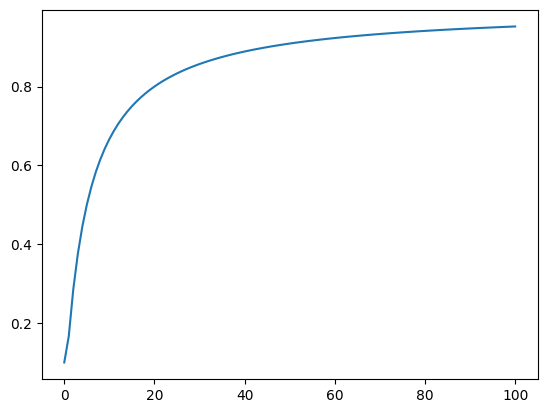

In [57]:
# gama1=np.zeros(M_It+1)
# for iterac in range(M_It):
#     gama1[iterac+1]=(.13 * (iterac+1) / (1 + .13 * (1+iterac)))  # Update gamma
print('Tiempo de cálculo:',TCalculo)
plt.plot(gama)

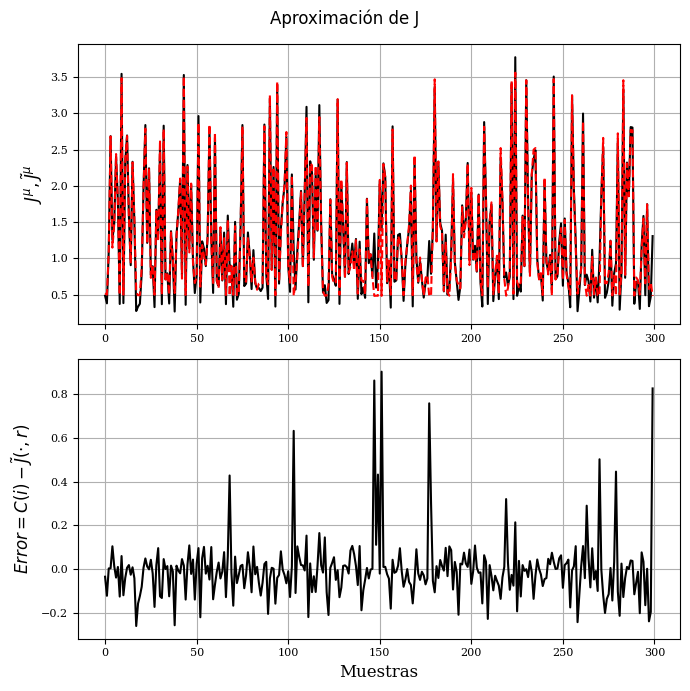

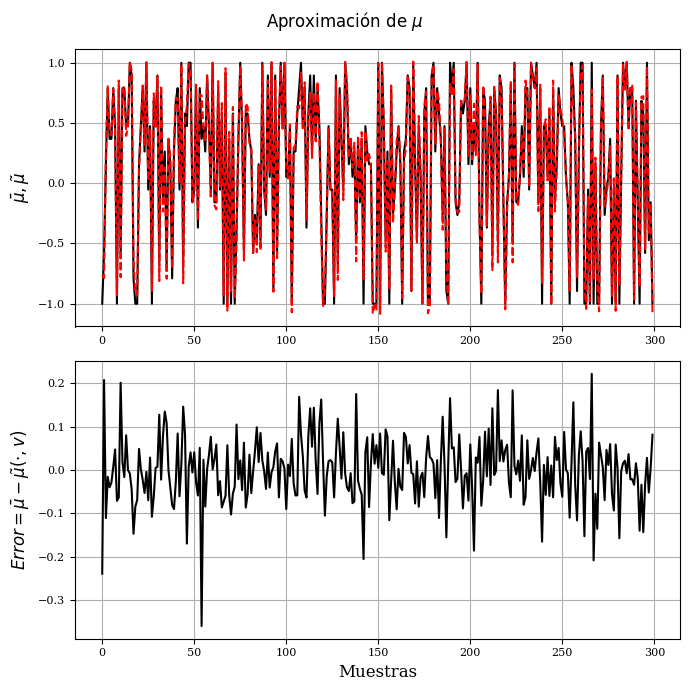

In [58]:
Yo_ap=np.zeros(len(Yo))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Yo_ap[k1] = mlp_J.predict(entrada.reshape(1, -1))[0]
Ya_ap=np.zeros(len(Ya))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Ya_ap[k1] = mlp_a.predict(entrada.reshape(1, -1))[0]
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de J')
axs[0].plot(Yo)
axs[0].plot(Yo_ap)
axs[0].set_ylabel(r'$J^{\mu},\tilde{J}^{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Yo-Yo_ap)
axs[1].set_ylabel(r'$Error=C(i)-\tilde{J}(\cdot,r)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de $\mu$')
axs[0].plot(Ya)
axs[0].plot(Ya_ap)
axs[0].set_ylabel(r'$\bar{\mu},\tilde{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Ya-Ya_ap)
axs[1].set_ylabel(r'$Error=\bar{\mu}-\tilde{\mu}(\cdot,v)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

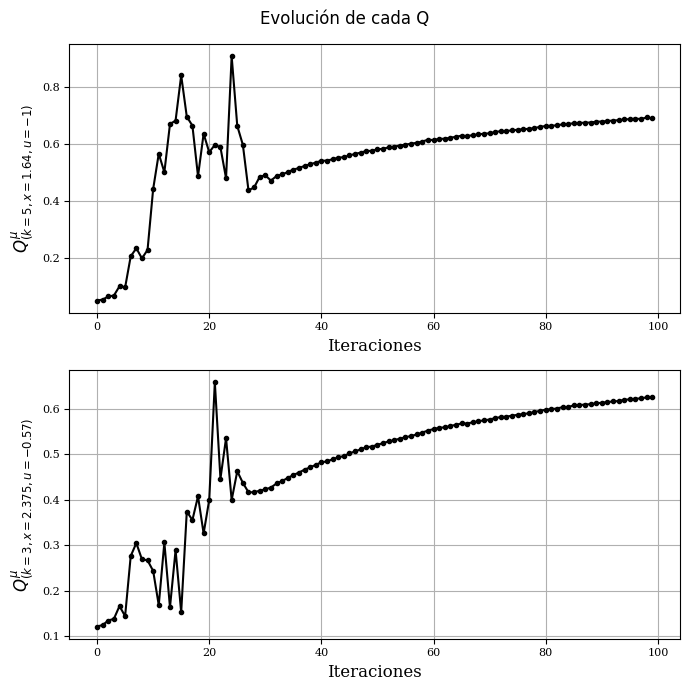

In [59]:
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de cada Q')
axs[0].plot(Q11, '.-')
axs[0].set_ylabel(r'$Q^{\mu}_{(k=5, x=1.64,u=-1)}$',rotation=90, fontsize=12)
axs[0].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(Q12, '.-')
axs[1].set_ylabel(r'$Q^{\mu}_{(k=3, x=2.375,u=-0.57)}$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

In [60]:
estado_tab=np.array(np.zeros((4,etapas)))
costo_tab=np.array(np.zeros((4,etapas)))
u_opt_tab=np.array(np.zeros((4,etapas-1)))
for CI_idx in range(4):
    inx = CI_idx
    estado_tab[CI_idx, 0] = inx
    for k in range(etapas - 1):
        entrada = np.array([[k, inx]])
        # an = pol_tab_mu1(entrada, M_est, Ya)        np.array([[k, sal[k]]])  # entrada = np.array([[k, x]])
        an = mlp_a.predict(entrada)[0] #pol_tab_mu1(entrada, M_est, Ya)
        u_opt_tab[CI_idx, k] = an
        costo_tab[CI_idx, k + 1] = indice(k, inx, an) + costo_tab[CI_idx, k]
        inx = mopdm(k, inx, an)
        estado_tab[CI_idx, k + 1] = inx
    costo_tab[CI_idx, -1] += np.abs(inx - 1)

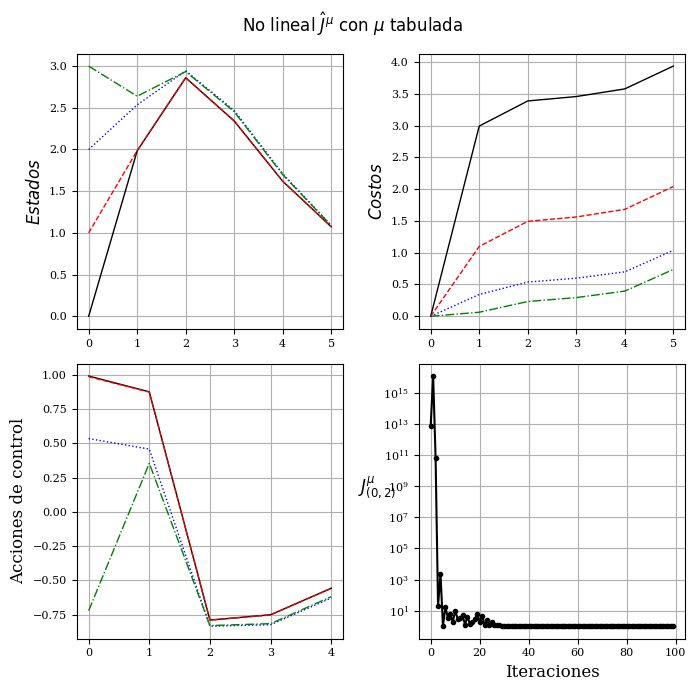

In [61]:
# Gráficos
xx = np.arange(etapas)
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'No lineal $\hat{J}^{\mu}$ con $\mu$ tabulada')
axs[0,0].plot(xx, estado_tab.T, linewidth =1.0)
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
axs[0,1].plot(xx, costo_tab.T, linewidth =1.0)
axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
axs[0,1].grid( True )
axs[1,0].plot(xx[:-1], u_opt_tab[:, :].T, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
axs[1,1].semilogy(evoluc, '.-')
axs[1,1].set_ylabel(r'$J^{\mu}_{(0,2)}$',rotation=0, fontsize=12)
axs[1,1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1,1].grid( True )
plt.tight_layout()
plt.show()

Nótese que aún con la inestabilidad inicial en el ajuste del algoritmo, se llega a una solución que cumple con las condiciones impuestas en la Formulación del problema básico de control óptimo.

# Dos variables de estado PDA con $\tilde J{(\cdot ,\textbf r)}$ y política también $\tilde {\mu(\cdot ,\textbf v)}$ aproximada

Caso de dos variables de estado, sin tiempo terminal fijado.

El sistema es $F(s)=\frac{3}{s^2+2s+3}$

$\dot{x}=Ax+Bu$

$y=Cx$

A =[-2    -3
     1     0];
B =[1;
     0];
C=[0, 3]


### Índice

In [ ]:
def indice_g( x, accion):
  # xd=np.array([0,.3333])
  err=x #Regulador a cero
  Q=np.diag([1., 1000.]) ; tita2=1e-6; umin=0; umax=2.;pon=0.
  if accion > umax:
    pon=np.abs(accion -umax)
  if accion > umin:
    pon=np.abs(umin-accion)
  y = err.T@Q@err + tita2*pon
  return y

In [36]:
def indice_g( x, accion):
  Mat_C=np.array([0,.3])
  # C =[     0     .3]
  # yd=0.
  # err=yd-Mat_C@x
  err=x
  Q=np.diag([500., 1000.]); tita2=1e-6; umin=-20; umax=20.;pon=0.
  if accion > umax:
    pon=np.abs(accion -umax)
  if accion > umin:
    pon=np.abs(umin-accion)
  # y = Q*err**2 + tita2*pon
  y = err.T@ Q @err + tita2*pon
  return y

### Modelo inestable

El sistema es $F(s)=\frac{0.3}{s^2+1.9s-0.2}$

$\dot{x}=Ax+Bu$

$y=Cx$

A =[-1.9    0.2
     1     0];
B =[1;
     0];
C=[0, 0.3]

In [6]:
def mod2ve(t_etapa, xant, accion):
#     """
#     Parámetros:
#     entrada : lista o array con dos elementos ix1, ix2
#     Retorna:
#     x : estado siguiente, dos componentes
  #        0.3
  # -----------------
  # s^2 + 1.9 s - 0.2
# num=[.3 ]
# den=conv([1 -.1],[1 2])
# G=tf(num,den)
# step(G)
# [A,B,C,D]=tf2ss(num,den);
# # K=place(A,B,[-1,-10])  K=place(A,B,[-1,-10])
# K =   9.100000000000000  10.199999999999998
# A =
#   -1.900000000000000   0.200000000000000
#    1.000000000000000                   0
# B =
#      1
#      0
# C =
#                    0   0.300000000000000
#     """
  h=.05;
  A =np.array([[-1.9,.2],[1, 0]]);
  B =np.array([[1],[0]]);  # h=.05;
  # % C =[     0     .3]
  # A =np.array([[-2,-3],[1, 0]]);
  # B =np.array([[1],[0]]);
  # % C =[     0     3]
  x=xant;u=accion;
  for ii in range(int(np.ceil(t_etapa/h))):
      xp=A@x+B*u;
      x=x+xp*h;
  return x

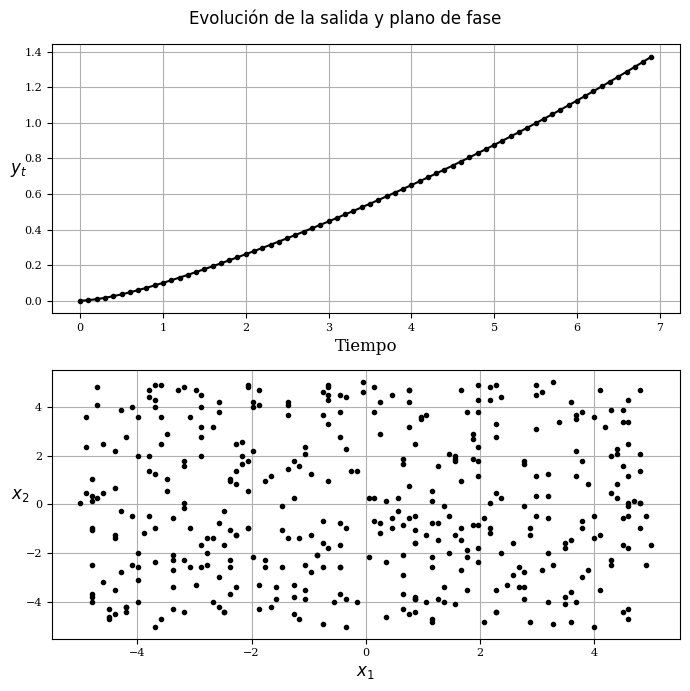

In [ ]:
Mat_C=np.array([0,.3])
TT=70
T0=.1
accion=np.ones(TT)
y=np.zeros(TT)
ty=np.zeros(TT)
sx=np.array([[0],[0]])
Mat_C=np.array([0,.3]);
for i in range(TT):
  sx=mod2ve(T0,sx,accion[i])
  y[i]=(Mat_C@sx)[0]
  ty[i]=T0*i
# plt.plot(ty,y)
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de la salida y plano de fase')
axs[0].plot(ty,y, '.-')
axs[0].set_ylabel(r'$y_t$',rotation=0, fontsize=12)
axs[0].set_xlabel(r'Tiempo',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(M_est[0,:],M_est[1,:],'.')
axs[1].set_ylabel(r'$x_2$',rotation=0, fontsize=12)
axs[1].set_xlabel(r'$x_1$',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

### Algoritmo neurocontrolador

In [37]:
from sklearn.neural_network import MLPRegressor
np.random.seed(0) # Set random seed for reproducibility
Mat_C=np.array([0,.3])
Nmax=100; Mmax=9;
t_etapa=.2; etapas=10; T0=t_etapa; #ref=[0; 0];%La referencia es nula.
dx=Nmax; du=Mmax;
x1=np.zeros(dx);
x2=np.zeros(dx);
# Max_it=20
# Inicialización
start_time = time.time()
TM = 500
r_x=5.;r_u=4.
# Generate control inputs (uf)
umin=-r_u;   umax=r_u;
Au = (umax - umin) / (Mmax - 1)
uf = np.array([umin + Au * (i - 1) for i in range(1, Mmax + 1)])
x1min=-r_x;  x1max=r_x;x2min=-r_x;  x2max=r_x;
Ax1=(x1max - x1min)/(Nmax - 1);
Ax2=(x2max - x2min)/(Nmax - 1);
Au =(umax - umin)/(Mmax - 1);
for i in range(Nmax):
    x1[i]=x1min + Ax1*i
    x2[i]=x2min + Ax2*i
# Generate random data for M_est
# Supongamos que estas variables ya están definidas:
# dx: tamaño del dominio en x
# TM: tamaño de la población
# x1, x2: vectores de datos
# etapas: número de etapas
# Generar posiciones aleatorias
A_posi_x1 = np.round((dx - 1) * np.random.rand(TM)).astype(int)
A_posi_x2 = np.round((dx - 1) * np.random.rand(TM)).astype(int)
# Crear vector de etapas
xx = np.arange(etapas)
# Obtener valores de x1 y x2 en las posiciones generadas
posi_x1 = x1[A_posi_x1]
posi_x2 = x2[A_posi_x2]
# Crear matriz M_est con dos filas: posi_x1 y posi_x2
M_est = np.vstack((posi_x1, posi_x2))
Ho = 3 #Neuronas ocultas
mlp_J = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.1, activation='tanh', solver='lbfgs',
                   max_iter=1000,  random_state=0)
mlp_a = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.1, activation='tanh', solver='lbfgs',
                   max_iter=1000,  random_state=0)
# Initialize data structures
Q = np.zeros((TM, len(uf)))
J = np.zeros(TM)
Ya = np.zeros(TM)
Ya= np.random.randn(TM)
sal = np.zeros(etapas)
costo = np.zeros(etapas)
M_It = 20 #-------------------------Número de iteraciones-------------------------
gama =np.zeros(M_It+1)
gama[0] = 0.1
Q11 =np.zeros(M_It)
Q12 =np.zeros(M_It)
evoluc=np.zeros(M_It)
Yo = np.zeros(TM)
PHI = M_est.copy()
X_train = PHI.T  #
Max_Ya=1.
mlp_a.fit(X_train, Ya) #primer ley de control aleatoria
# Main iteration loop
for iterac in range(M_It):
    # Compute costs for each sample in M_est
    for iq in range(TM):
        Jc = np.zeros([etapas])
        x_1 = M_est[0, iq]
        x_2 = M_est[1, iq]
        xy=np.array([x_1,x_2])
        for k in range( etapas - 1):
            entrada = np.array([xy])
            u = Max_Ya*mlp_a.predict(entrada)[0]
            Jc[k] = indice_g( xy, u)
            xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
            xy=xj.flatten()
        Yo[iq]=0
        for k in range(etapas,0,-1):
          Yo[iq] = Jc[k-1]+gama[iterac]*Yo[iq]
    #Normalizar a los J deseados
    Max_Yo=np.max(Yo)
    Yo=Yo/Max_Yo
    # Train neural network
    if iterac>0:
      mlp_J.coefs_ = pesos_guardados
      mlp_J.intercepts_ = bias_guardados
    mlp_J.fit(X_train, Yo)
    # Guardar los pesos
    pesos_guardados = mlp_J.coefs_.copy()
    bias_guardados = mlp_J.intercepts_.copy()
    # Compute Q-values
    for iq in range(TM):
        x_1 = M_est[0, iq]
        x_2 = M_est[1, iq]
        x =np.array([x_1,x_2])
        for acc in range(len(uf)):
            xj = mod2ve(t_etapa, x.reshape(-1, 1), uf[acc])
            xy=xj.flatten()
            entrada = np.array([xy])
            y2 = mlp_J.predict(entrada)[0]
            y2 = max(0, y2)  # ReLU-like behavior
            Q[iq, acc] = indice_g( x, uf[acc]) + gama[iterac] * Max_Yo*y2
    # Update policy
    for iq in range(TM):
        val = np.min(Q[iq, :])
        lugar = np.argmin(Q[iq, :])
        J[iq] = val
        Ya[iq] = uf[lugar]
        # Train neural network
    #Normalizar a mu
    Max_Ya=np.max(Ya)
    Ya=Ya/Max_Ya
    if iterac>0:
      mlp_a.coefs_ = pesos_guardados_a
      mlp_a.intercepts_ = bias_guardados_a
    mlp_a.fit(X_train, Ya)
    # Guardar los pesos de la red acción
    pesos_guardados_a = mlp_a.coefs_.copy()
    bias_guardados_a = mlp_a.intercepts_.copy()
    # gama[iterac+1]=(.3 * (iterac+1) / (1 + .3 * (1+iterac)))  # Si
    # gama[iterac+1]=(.2 * (iterac+1) / (1 + .2 * (1+iterac)))  # Update gamma
        # gamma(iterac)=(.5*iterac/(1 + .5*iterac));
    gama[iterac+1]=(.5 * (iterac+1) / (1 + .5 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(.13 * (iterac+1) / (1 + .13 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(5 * (iterac+1) / (5 + 5 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(.7 * (iterac+1) / (1 + .7 * (1+iterac)))  # NO
    Q11[iterac]=Q[49,0]
    Q12[iterac]=Q[10,3]
    # Evaluate policy
    x_p=np.array([0, 0])
    costo = np.zeros(etapas)
    for k in range(etapas - 1):
        entrada = np.array([x_p])  # entrada = np.array([[k, x]])
        consigna = Max_Ya*mlp_a.predict(entrada)[0] #pol_tab_mu1(entrada, M_est, Ya)
        xj= mod2ve(t_etapa, x_p.reshape(-1, 1), consigna)
        x_p=xj.flatten()
        costo[k + 1] = costo[k] + indice_g(x_p, consigna)
    # costo[etapas - 1] += abs(sal[etapas - 1] - vfinal)
    evoluc[iterac]=costo[etapas - 1]
    print(f"Costo final: {evoluc[iterac]}", f"Iteración: {iterac}", f" de: {M_It}")
# disp(['Iteración ' num2str(iterac) ' de ' num2str(Max_it) sprintf('\t') 'Cost-to-go ' sprintf('%d ',evoluc(iterac)) ]);% as=[' sprintf('%d ',as) '];'])
TCalculo = time.time() - start_time
print('Tiempo de cálculo:',TCalculo)

Costo final: 1666.9727126046078 Iteración: 0  de: 20
Costo final: 1103.6582097513783 Iteración: 1  de: 20
Costo final: 808.227014081934 Iteración: 2  de: 20
Costo final: 355.5662569405134 Iteración: 3  de: 20
Costo final: 931.081555532867 Iteración: 4  de: 20
Costo final: 52.08521236235323 Iteración: 5  de: 20
Costo final: 64.47442989166535 Iteración: 6  de: 20
Costo final: 48.72017229513087 Iteración: 7  de: 20
Costo final: 37.29566910737857 Iteración: 8  de: 20
Costo final: 30.383710591108617 Iteración: 9  de: 20
Costo final: 17.661118616543124 Iteración: 10  de: 20
Costo final: 30.440860581786428 Iteración: 11  de: 20
Costo final: 19.886172473489697 Iteración: 12  de: 20
Costo final: 44.418970543629875 Iteración: 13  de: 20
Costo final: 44.418970543629875 Iteración: 14  de: 20
Costo final: 36.54728047405547 Iteración: 15  de: 20
Costo final: 37.923358246933674 Iteración: 16  de: 20
Costo final: 41.173652760195665 Iteración: 17  de: 20
Costo final: 36.34714260976178 Iteración: 18  de

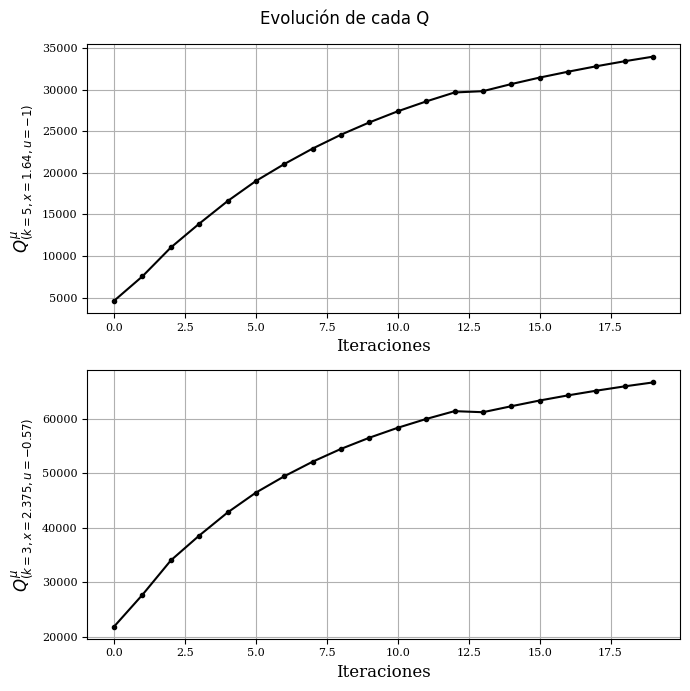

In [38]:
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de cada Q')
axs[0].plot(Q11, '.-')
axs[0].set_ylabel(r'$Q^{\mu}_{(k=5, x=1.64,u=-1)}$',rotation=90, fontsize=12)
axs[0].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(Q12, '.-')
axs[1].set_ylabel(r'$Q^{\mu}_{(k=3, x=2.375,u=-0.57)}$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

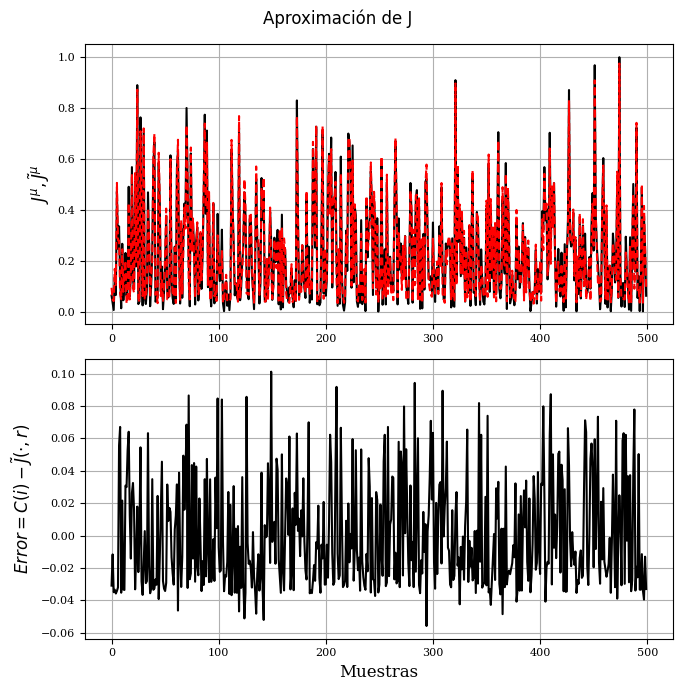

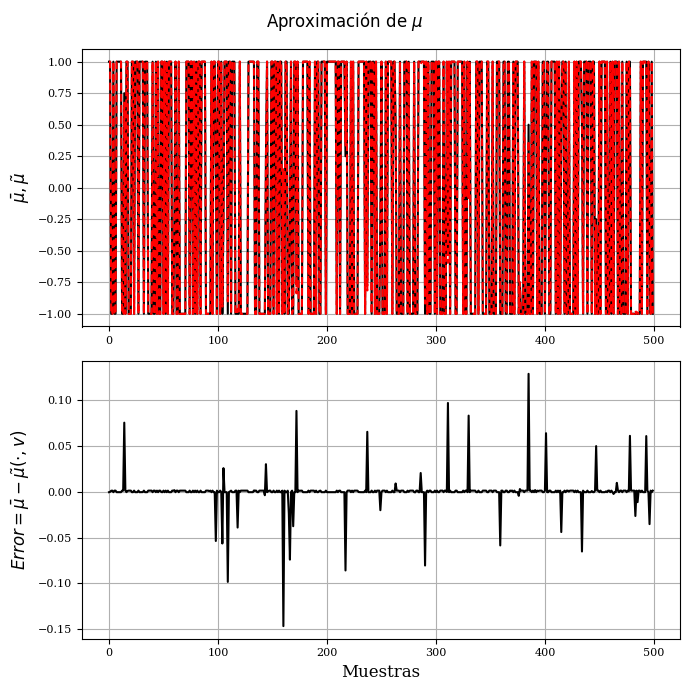

In [39]:
Yo_ap=np.zeros(len(Yo))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Yo_ap[k1] = mlp_J.predict(entrada.reshape(1, -1))[0]
Ya_ap=np.zeros(len(Ya))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Ya_ap[k1] = mlp_a.predict(entrada.reshape(1, -1))[0]
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de J')
axs[0].plot(Yo)
axs[0].plot(Yo_ap)
axs[0].set_ylabel(r'$J^{\mu},\tilde{J}^{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Yo-Yo_ap)
axs[1].set_ylabel(r'$Error=C(i)-\tilde{J}(\cdot,r)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de $\mu$')
axs[0].plot(Ya)
axs[0].plot(Ya_ap)
axs[0].set_ylabel(r'$\bar{\mu},\tilde{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Ya-Ya_ap)
axs[1].set_ylabel(r'$Error=\bar{\mu}-\tilde{\mu}(\cdot,v)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

### Evolución del sistema

In [52]:
etapas1=2500
u_opt_tab=np.zeros(etapas1)
costo_tab=np.zeros(etapas1)
y_s=np.zeros(etapas1)
x_s=np.zeros((2,etapas1))
t_t=np.zeros(etapas1)
Jc=0;iq=12
x_1 = M_est[0, iq]
x_2 = M_est[1, iq]
x_1,x_2=-7.,-7.
xy =np.array([x_1,x_2]); ve=0.; KI=1e-3
# Valores de referencia no nula sólo para x_2
xref =np.array([0.,1.]);ref=Mat_C@xref
for k in range( etapas1):
  y_s[k]=Mat_C@xy
  e1=Mat_C@xy-ref
  ve=ve+e1
  x_s[:,k]=xy
  entrada = np.array([xy-xref])
  u = Max_Ya*mlp_a.predict(entrada)[0] + KI*ve
  # u = ley_control(xy-xref, W1a, W2a)[0]+KI*ve1
  u_opt_tab[k] = u
  xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
  xy=xj.flatten()
  t_t[k]=k*t_etapa
  costo_tab[k] = Jc
  Jc += indice_g( xy, u) # plt.plot(y_s)
print('Error de estado= ', xy-xref)
  # e1=xy[0]-ref1
  # ve1=ve1+e1 #Acumula error, PI en TD
  # y_s[k]=Mat_C@xy
  # x_s[:,k]=xy
  # # entrada = np.array([xy])
  # # u = Max_Ya*mlp_a.predict(entrada)[0]
  # # entrada = np.append(xy, 1)
  # u = ley_control(xy-xref, W1a, W2a)[0]+KI*ve1

Error de estado=  [-3.43086820e-06 -4.24102039e-02]


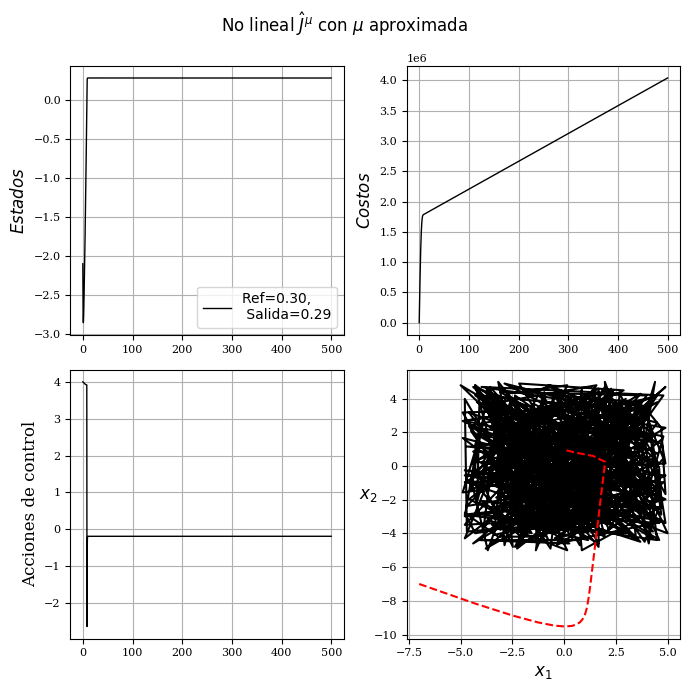

In [53]:
# Gráficos
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'No lineal $\hat{J}^{\mu}$ con $\mu$ aproximada')
axs[0,0].plot(t_t, y_s.T, linewidth =1.0, label=f'Ref={ref:.2f}, \n Salida={y_s[-1]:.2f}')
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
axs[0,0].legend()
axs[0,1].plot(t_t, costo_tab, linewidth =1.0)
axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
axs[0,1].grid( True )
axs[1,0].plot(t_t, u_opt_tab, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
# axs[1,1].semilogy(evoluc, '.-')
axs[1,1].plot(M_est[0,:], M_est[1,:], markersize=.00001,  marker='.')
axs[1,1].plot(x_s[0,:], x_s[1,:])
axs[1,1].set_ylabel(r'$x_2$',rotation=0, fontsize=12)
axs[1,1].set_xlabel(r'$x_1$',rotation=0, fontsize=12)
axs[1,1].grid( True )
plt.tight_layout()
plt.show()

## Neurocontrolador para el péndulo

### Control DLQR para el Péndulo invertido

Para un tiempo de muestreo $t_s=0,1seg.$ se ha calculado con un índice cuadrático del tipo,


$J(x)=\sum_{k=0}^{k=\infty} x_k^TQx_k+u_k^TRu_k$


donde

$Q=
\begin{bmatrix}
10^2 & 0 & 0 & 0\\
0 & 10 & 0 & 0\\
0 & 0 & 10^4 & 0\\
0 & 0 & 0 & 10^8
\end{bmatrix}$

y $R=10^{-4}$

Es decir, Qc=diag([1e2 1e1 1e4 1e8); R=1e-4; %Ts=0.1;.
Se obtuvo el valor del controlador K, como $K=\bigl[\begin{smallmatrix}-0.002870476685015& -0.128014810037601& -7.239333735045133& -3.307058843766033 \end{smallmatrix}\bigr]$

Es decir,
K=[-0.002870476685015  -0.128014810037601  -7.239333735045133 -3.307058843766033],

o

K=np.array([-0.002870476685015,-0.128014810037601,-7.239333735045133,-3.307058843766033])

### Índice

In [ ]:
def indice_g( x, accion):
    """
    # % Indice
    # % x: Estado actual
    # % k: Paso en el que se encuentra
    # % accion: Accion de control aplicada
    """
    umin=-50; umax=50; pon=0;
    if (accion > umax):
      pon = 50*(accion-umax)
    if (accion < umin):
      pon = 50*abs(umin-accion)
    y = x.T@np.diag([ 150, 0.5, 100, 0.5])@x + pon +  1e-2*accion**2
    return y

### Modelo

In [ ]:
def mopdm(tiempo_etapa, xant, accion):
    """
    Péndulo didáctico tomado de Sontag Pag 104 Mathematical control theory 1998.
    El controlador es un LQR, sólo para el punto de equilibrio inestable superior,
    con ángulo próximo a cero.
    Parameters:
    -----------
    tiempo_etapa : float
        Tiempo de simulación para esta etapa
    xant : array_like
        Estado anterior [p, p_p, alfa, omega]
    accion : float
        Acción de control aplicada
    Returns:
    --------
    X : ndarray
        Nuevo estado [p, p_p, alfa, omega]
    """
    # Parámetros del sistema
    m = 0.1
    Fricc = 0.1
    long = 0.6
    g = 9.8
    M = 0.5
    # Paso de integración
    h = 0.0001
    # Estado inicial
    p = xant[0]
    p_p = xant[1]
    alfa = xant[2]
    omega = xant[3]
    # Integración por Euler
    n_pasos = int(tiempo_etapa / h)
    tita_pp = 0.
    for i in range(n_pasos):
        # Calcular aceleraciones
        p_pp = (1 / (M + m)) * (accion - m * long * tita_pp * np.cos(alfa) + m * long * omega**2 * np.sin(alfa) - Fricc * p_p)
        #    p_pp=(1/(M+m))*(accion-m*long* tita_pp *cos(alfa)+m*long*omega^2*sin(alfa)-Fricc*p_p);
        tita_pp = (1 / long) * (g * np.sin(alfa) - p_pp * np.cos(alfa))
        # tita_pp=(1/long)*(g*sin(alfa)-p_pp*cos(alfa));
       # Integrar posiciones
        p = p + h * p_p
        alfa = alfa + h * omega
         # Integrar velocidades
        p_p = p_p + h * p_pp
        omega = omega + h * tita_pp
    return np.array([p, p_p, alfa, omega])

### Control lineal con el modelo del Péndulo

In [ ]:
etapas1=1500
t_etapa=1e-1;K_M=np.array([-0.0014 ,  -0.1177 ,  -6.9282 ,  -3.2857])
K_M=np.array([-0.002870476685015,-0.128014810037601,-7.239333735045133,-3.307058843766033])
# t_etapa=1e-1; # K_M =      -0.0014   -0.1177   -6.9282   -3.2857
Mat_C=np.array([0., 0., 1., 0.])
u_opt_tab=np.zeros(etapas1)
costo_tab=np.zeros(etapas1)
y_s=np.zeros(etapas1)
x_s=np.zeros((4,etapas1))
t_t=np.zeros(etapas1)
Jc=0; iq=25
# x_1 = 1*M_est[0, iq]
# x_2 = -5*M_est[1, iq]
x_1,x_2,x_3,x_4= [0., 0., -3.1, 0.]
xy =np.array([x_1,x_2,x_3,x_4])
for k in range( etapas1):
  y_s[k]=Mat_C@xy
  x_s[:,k]=xy
  entrada = np.array([xy])
  # u = Max_Ya*mlp_a.predict(entrada)[0]
  u = -K_M @ entrada[0] #Controlador lineal
  u_opt_tab[k] = u
  # xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
  xj = mopdm(t_etapa, xy, u)
  xy=xj.flatten()
  t_t[k]=k*t_etapa
  costo_tab[k] = Jc
  Jc += indice_g( xy, u) # plt.plot(y_s)

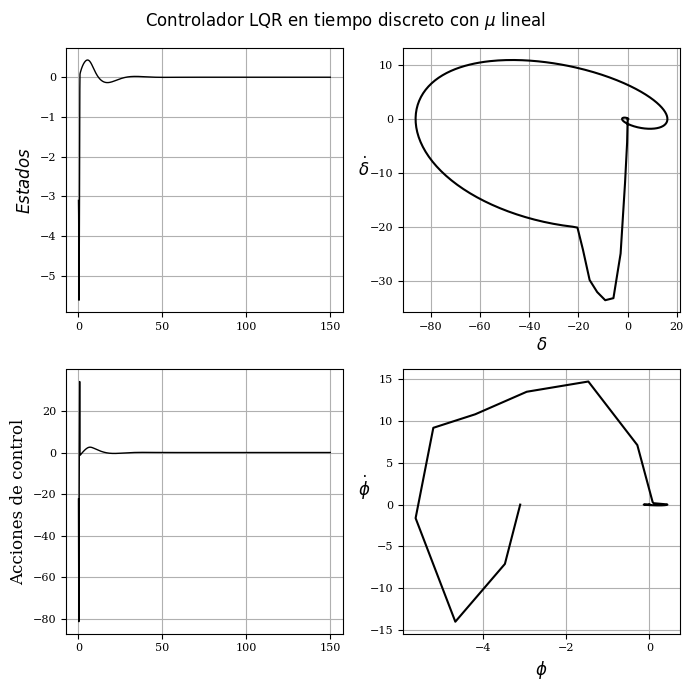

In [ ]:
# Gráficos
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'Controlador LQR en tiempo discreto con $\mu$ lineal')
axs[0,0].plot(t_t, y_s.T, linewidth =1.0)
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
# axs[0,1].plot(t_t, costo_tab, linewidth =1.0)
# axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
# axs[0,1].grid( True )
axs[1,0].plot(t_t, u_opt_tab, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
axs[0,1].plot(x_s[0,:], x_s[1,:])
axs[0,1].set_ylabel(r'$\dot \delta$',rotation=0, fontsize=12)
axs[0,1].set_xlabel(r'$\delta$',rotation=0, fontsize=12)
axs[0,1].grid( True )
# axs[1,1].semilogy(evoluc, '.-')
# axs[1,1].plot(M_est[0,:], M_est[1,:], '.')
axs[1,1].plot(x_s[2,:], x_s[3,:])
axs[1,1].set_ylabel(r'$\dot \phi$',rotation=0, fontsize=12)
axs[1,1].set_xlabel(r'$\phi$',rotation=0, fontsize=12)
axs[1,1].grid( True )
plt.tight_layout()
plt.show()

### Comentario
Las acciones de control son muy difíciles de limitar, ya que debe resolverse el problema LQR tn tiempo discreto y luego se verifican las restricciones del actuador.

In [ ]:
entrada[0]

array([-1.20537805e-05,  1.60392532e-06,  1.78385615e-08, -1.13502812e-08])

In [ ]:
### Algoritmo neurocontrolador
from sklearn.neural_network import MLPRegressor
# Set random seed for reproducibility
np.random.seed(0)
Nmax=100; Mmax=11;
t_etapa=.1; etapas=15; T0=t_etapa; #ref=[0; 0];%La referencia está en el índice.
dx=Nmax; du=Mmax;
x1=np.zeros(dx); x2=np.zeros(dx);
x3=np.zeros(dx); x4=np.zeros(dx);
# Inicialización
start_time = time.time()
TM = 100 # ---------------------------------Éste valor debe ser1000 o 2000
r_delta=3.;r_fi=.9;r_u=20.
# Generate control inputs (uf)
umin=-r_u;   umax=r_u;
Au = (umax - umin) / (Mmax - 1)
uf = np.array([umin + Au * (i - 1) for i in range(1, Mmax + 1)])
x1min=-r_delta;  x1max=r_delta; x2min=-2*r_delta;  x2max=2*r_delta;
x3min=-r_fi;  x3max=r_fi; x4min=-5*r_fi;  x4max=5*r_fi;
Ax1=(x1max - x1min)/(Nmax - 1);
Ax2=(x2max - x2min)/(Nmax - 1);
Ax3=(x3max - x3min)/(Nmax - 1);
Ax4=(x4max - x4min)/(Nmax - 1);
Au =(umax - umin)/(Mmax - 1);
for i in range(Nmax):
    x1[i]=x1min + Ax1*i
    x2[i]=x2min + Ax2*i
    x3[i]=x3min + Ax3*i
    x4[i]=x4min + Ax4*i
# Generate random data for M_est
A_posi_x1 = np.round((dx - 1) * np.random.rand(TM)).astype(int)
A_posi_x2 = np.round((dx - 1) * np.random.rand(TM)).astype(int)
A_posi_x3 = np.round((dx - 1) * np.random.rand(TM)).astype(int)
A_posi_x4 = np.round((dx - 1) * np.random.rand(TM)).astype(int)
# Crear vector de etapas
xx = np.arange(etapas)
# Obtener valores de x1 y x2 en las posiciones generadas
posi_x1 = x1[A_posi_x1]
posi_x2 = x2[A_posi_x2]
posi_x3 = x3[A_posi_x3]
posi_x4 = x4[A_posi_x4]
# Crear matriz M_est con cuatro filas: posi_x1 2 3 y 4
M_est = np.vstack((posi_x1, posi_x2, posi_x3, posi_x4))
Ho = 7 #Neuronas ocultas
mlp_J = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.12, activation='tanh', solver='lbfgs',
                   max_iter=100,  random_state=0)
mlp_a = MLPRegressor(hidden_layer_sizes=(Ho,), warm_start=True,  early_stopping=True, validation_fraction=0.12, activation='tanh', solver='lbfgs',
                   max_iter=100,  random_state=0)
# Initialize data structures
Q = np.zeros((TM, len(uf)))
J = np.zeros(TM)
Ya = np.zeros(TM)
Ya= np.random.randn(TM)
sal = np.zeros(etapas)
costo = np.zeros(etapas)
M_It = 1#-------------------------Número de iteraciones debe ser 150------------
gama =np.zeros(M_It+1)
gama[0] = 0.1
Q11 =np.zeros(M_It)
Q12 =np.zeros(M_It)
evoluc=np.zeros(M_It)
Yo = np.zeros(TM)
PHI = M_est.copy()
X_train = PHI.T  #
Max_Ya=1.
mlp_a.fit(X_train, Ya) #primer ley de control aleatoria
mlp_a.coefs_[0]=  np.array([[ 1.11254202, -2.33460471,  0.15798391, -1.97816684, -0.99933366,
         0.68728718,  0.10371299],
       [ 3.85507004,  3.56625359,  0.20276437, -0.40712279, -1.41184961,
        -3.40870584,  0.14420244],
       [-1.48076841,  0.02298456,  2.14330518,  1.83708206,  3.74823495,
         1.45085704,  1.67411142],
       [ 3.13852928, -2.21460129,  0.30332796, -3.01316001,  1.17448156,
        -6.86431407,  0.26766564]])
mlp_a.coefs_[1]=np.array([[ 0.01803864],
       [ 0.01703684],
       [-2.35774694],
       [ 0.03522243],
       [ 0.07909146],
       [ 0.03719998],
       [ 3.5029954 ]])
mlp_a.intercepts_[0] =  np.array([-1.1195964 , -4.13063816, -0.12314813,  2.14361176, -2.9717249 ,
        4.6141772 , -0.23906463])
mlp_a.intercepts_[1] =  np.array([0.1374423])
# mlp.coefs_[0] = np.array([[0.1, 0.2, 0.3, 0.4, 0.5],
#                           [0.6, 0.7, 0.8, 0.9, 1.0]])  # capa de entrada a oculta

# mlp.coefs_[1] = np.array([[0.1, 0.2, 0.3],
#                           [0.4, 0.5, 0.6],
#                           [0.7, 0.8, 0.9],
#                           [1.0, 1.1, 1.2],
#                           [1.3, 1.4, 1.5]])  # capa oculta a salida

# mlp.intercepts_[0] = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
# mlp.intercepts_[1] = np.array([0.1, 0.2, 0.3])
# Main iteration loop
for iterac in range(M_It):
    # Compute costs for each sample in M_est
    for iq in range(TM):
        Jc = 0
        x_1 = M_est[0, iq]
        x_2 = M_est[1, iq]
        x_3 = M_est[2, iq]
        x_4 = M_est[3, iq]
        xy=np.array([x_1,x_2,x_3,x_4])
        for k in range( etapas - 1):
            entrada = np.array([xy])
            u = Max_Ya*mlp_a.predict(entrada)[0]
            Jc += indice_g( xy, u)
            # xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
            # xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
            xj = mopdm(t_etapa, xy.reshape(-1, 1), u)
            xy=xj.flatten()
        Yo[iq] = Jc
    #Normalizar a J
    Max_Yo=np.max(Yo)
    Yo=Yo/Max_Yo
    # Train neural network     # X_train = PHI.T  # bias term
    if iterac>0:
      mlp_J.coefs_ = pesos_guardados
      mlp_J.intercepts_ = bias_guardados
    mlp_J.fit(X_train, Yo)
    # Guardar los pesos
    pesos_guardados = mlp_J.coefs_.copy()
    bias_guardados = mlp_J.intercepts_.copy()
    # Compute Q-values
    for iq in range(TM):
        x_1 = M_est[0, iq]
        x_2 = M_est[1, iq]
        x_3 = M_est[2, iq]
        x_4 = M_est[3, iq]
        x=np.array([x_1,x_2,x_3,x_4])
        for acc in range(len(uf)):
            # xj = mod2ve(t_etapa, x.reshape(-1, 1), uf[acc])
            xj = mopdm(t_etapa, x.reshape(-1, 1), uf[acc])
            xy=xj.flatten()
            entrada = np.array([xy])
            y2 = mlp_J.predict(entrada)[0]
            y2 = max(0, y2)  # ReLU-like behavior
            Q[iq, acc] = indice_g( x, uf[acc]) + gama[iterac] * Max_Yo*y2
    # Update policy
    for iq in range(TM):
        val = np.min(Q[iq, :])
        lugar = np.argmin(Q[iq, :])
        J[iq] = val
        Ya[iq] = uf[lugar]
        # Train neural network
    #Normalizar a mu
    Max_Ya=np.max(Ya)
    Ya=Ya/Max_Ya
    if iterac>0:
      mlp_a.coefs_ = pesos_guardados_a
      mlp_a.intercepts_ = bias_guardados_a
    mlp_a.fit(X_train, Ya)
    # Guardar los pesos de la red acción
    pesos_guardados_a = mlp_a.coefs_.copy()
    bias_guardados_a = mlp_a.intercepts_.copy()
    # gama[iterac+1]=(.3 * (iterac+1) / (1 + .3 * (1+iterac)))  # Si
    # gama[iterac+1]=(.2 * (iterac+1) / (1 + .2 * (1+iterac)))  # Update gamma
        # gamma(iterac)=(.5*iterac/(1 + .5*iterac));
    gama[iterac+1]=(.2 * (iterac+1) / (1 + .2 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(.13 * (iterac+1) / (1 + .13 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(5 * (iterac+1) / (5 + 5 * (1+iterac)))  # Update gamma
    # gama[iterac+1]=(.7 * (iterac+1) / (1 + .7 * (1+iterac)))  # NO
    Q11[iterac]=Q[49,0]
    Q12[iterac]=Q[10,3]
    # Evaluate policy
    x_p=np.array([0, 0,.1,0])
    costo = np.zeros(etapas)
    for k in range(etapas - 1):
        entrada = np.array([x_p])  # entrada = np.array([[k, x]])
        consigna = Max_Ya*mlp_a.predict(entrada)[0] #pol_tab_mu1(entrada, M_est, Ya)
        # xj= mod2ve(t_etapa, x_p.reshape(-1, 1), consigna)
        xj = mopdm(t_etapa, x_p.reshape(-1, 1), consigna)
        x_p=xj.flatten()
        costo[k + 1] = costo[k] + indice_g(x_p, consigna)
    # costo[etapas - 1] += abs(sal[etapas - 1] - vfinal)
    evoluc[iterac]=costo[etapas - 1]
    print(f"Costo final: {evoluc[iterac]}", f"Iteración: {iterac+1}", f"  de {M_It}")
TCalculo = time.time() - start_time
print('Tiempo de cálculo:',TCalculo)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

Costo final: 2558.6631531053054 Iteración: 1   de 1
Tiempo de cálculo: 62.45051670074463


In [ ]:
# print('mlp_a.coefs_ = ', mlp_a.coefs_ , '\n',
# 'mlp_a.intercepts_ = ', mlp_a.intercepts_ , '\n',
# 'mlp_J.coefs_ = ', mlp_J.coefs_ , '\n',
# 'mlp_J.intercepts_ = ', mlp_J.intercepts_)

mlp_a.coefs_ =  [array([[ 2.69204074, -1.81897423,  0.2961904 , -1.8822658 , -1.30289009,
         0.77826151,  0.25465291],
       [ 3.26591156,  3.8678032 ,  0.10171184, -0.36825695, -0.90273324,
        -4.06569081,  0.12311505],
       [-1.53266143, -0.08113784, -0.45234841,  1.84922537,  3.75674349,
         1.47299692,  1.39490851],
       [ 3.39955315, -2.22846215,  0.02241332, -3.18224987,  1.22384978,
        -6.39334007,  0.31114784]]), array([[ 0.11058233],
       [-0.00982999],
       [-4.88587949],
       [ 0.01198152],
       [-0.04698022],
       [ 0.03094377],
       [ 1.04694572]])] 
 mlp_a.intercepts_ =  [array([ 0.41615597, -4.06081743, -2.72442865,  2.00814216, -2.91553355,
        4.79605824, -0.10154575]), array([-4.81290857])] 
 mlp_J.coefs_ =  [array([[-1.21867507e-01, -1.04149118e-02, -7.40137870e-02,
         1.31628487e-01,  4.31937833e-01,  1.66667992e-01,
        -5.04246161e-01],
       [ 7.57898010e-02, -5.46754747e-02,  2.66828230e-03,
         5.6038226

Recargo los coeficientes en Scikit learn

In [ ]:
mlp_a.coefs_[0]=  np.array([[ 1.11254202, -2.33460471,  0.15798391, -1.97816684, -0.99933366,
         0.68728718,  0.10371299],
       [ 3.85507004,  3.56625359,  0.20276437, -0.40712279, -1.41184961,
        -3.40870584,  0.14420244],
       [-1.48076841,  0.02298456,  2.14330518,  1.83708206,  3.74823495,
         1.45085704,  1.67411142],
       [ 3.13852928, -2.21460129,  0.30332796, -3.01316001,  1.17448156,
        -6.86431407,  0.26766564]])
mlp_a.coefs_[1]=np.array([[ 0.01803864],
       [ 0.01703684],
       [-2.35774694],
       [ 0.03522243],
       [ 0.07909146],
       [ 0.03719998],
       [ 3.5029954 ]])
mlp_a.intercepts_[0] =  np.array([-1.1195964 , -4.13063816, -0.12314813,  2.14361176, -2.9717249 ,
        4.6141772 , -0.23906463])
mlp_a.intercepts_[1] =  np.array([0.1374423])

In [ ]:
# Evaluate policy
x_p=np.array([0, 0,.1,0])
costo = np.zeros(etapas)
for k in range(etapas - 1):
    entrada = np.array([x_p])  # entrada = np.array([[k, x]])
    consigna = Max_Ya*mlp_a.predict(entrada)[0] #pol_tab_mu1(entrada, M_est, Ya)
    # xj= mod2ve(t_etapa, x_p.reshape(-1, 1), consigna)
    xj = mopdm(t_etapa, x_p.reshape(-1, 1), consigna)
    x_p=xj.flatten()
    costo[k + 1] = costo[k] + indice_g(x_p, consigna)
# costo[etapas - 1] += abs(sal[etapas - 1] - vfinal)
evoluc[iterac]=costo[etapas - 1]
print(x_p)

[ 2.87911749  3.62602371  0.06727056 -0.30820083]


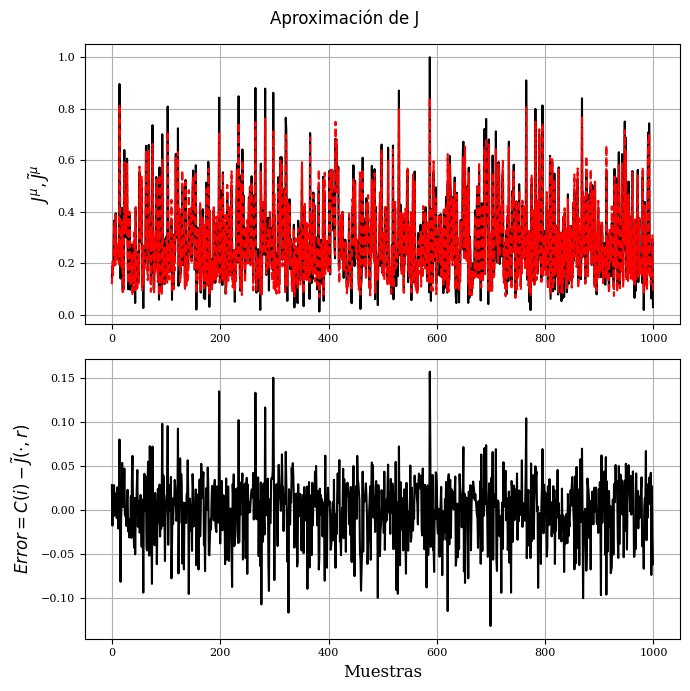

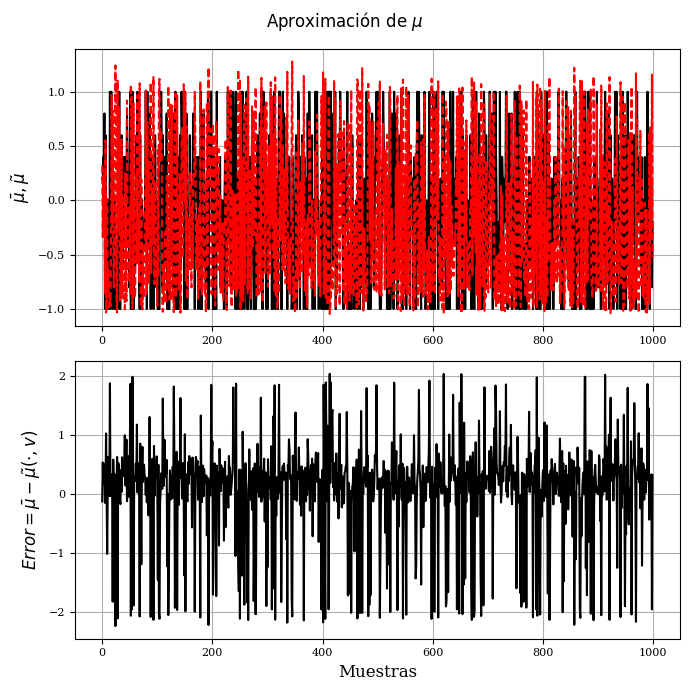

In [ ]:
Yo_ap=np.zeros(len(Yo))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Yo_ap[k1] = mlp_J.predict(entrada.reshape(1, -1))[0]
Ya_ap=np.zeros(len(Ya))
for k1 in range(len(Yo)):
  entrada=X_train[k1,:]
  Ya_ap[k1] = mlp_a.predict(entrada.reshape(1, -1))[0]
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de J')
axs[0].plot(Yo)
axs[0].plot(Yo_ap)
axs[0].set_ylabel(r'$J^{\mu},\tilde{J}^{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Yo-Yo_ap)
axs[1].set_ylabel(r'$Error=C(i)-\tilde{J}(\cdot,r)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de $\mu$')
axs[0].plot(Ya)
axs[0].plot(Ya_ap)
axs[0].set_ylabel(r'$\bar{\mu},\tilde{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Ya-Ya_ap)
axs[1].set_ylabel(r'$Error=\bar{\mu}-\tilde{\mu}(\cdot,v)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

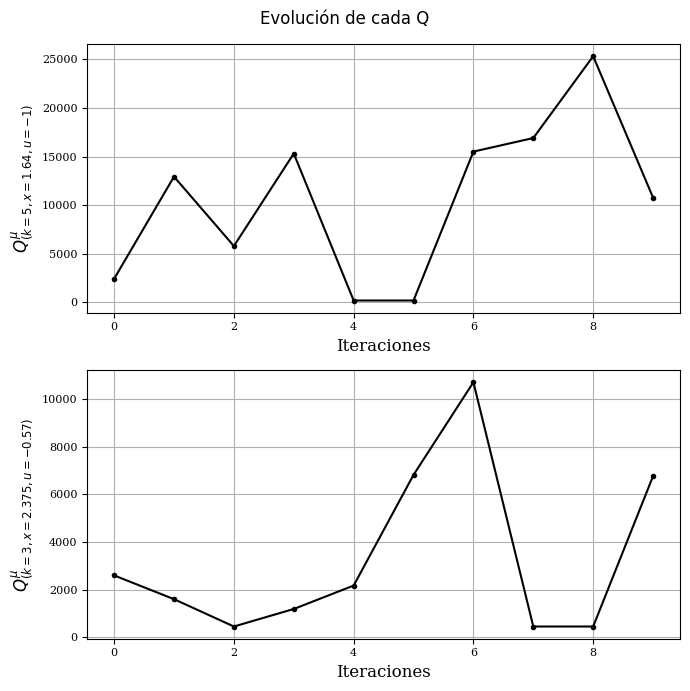

In [ ]:
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de cada Q')
axs[0].plot(Q11, '.-')
axs[0].set_ylabel(r'$Q^{\mu}_{(k=5, x=1.64,u=-1)}$',rotation=90, fontsize=12)
axs[0].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(Q12, '.-')
axs[1].set_ylabel(r'$Q^{\mu}_{(k=3, x=2.375,u=-0.57)}$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

### Evaluación de la ley de control

In [ ]:
etapas1=1500
t_etapa=1e-1;K_M=np.array([-0.0014 ,  -0.1177 ,  -6.9282 ,  -3.2857])
# t_etapa=1e-1; # K_M =      -0.0014   -0.1177   -6.9282   -3.2857
Mat_C=np.array([0., 0., 1., 0.])
u_opt_tab=np.zeros(etapas1)
costo_tab=np.zeros(etapas1)
y_s=np.zeros(etapas1)
x_s=np.zeros((4,etapas1))
t_t=np.zeros(etapas1)
Jc=0; iq=25
# x_1 = 1*M_est[0, iq]
# x_2 = -5*M_est[1, iq]
x_1,x_2,x_3,x_4= [0., 0., .7, 0.]
xy =np.array([x_1,x_2,x_3,x_4])
for k in range( etapas1):
  y_s[k]=Mat_C@xy
  x_s[:,k]=xy
  entrada = np.array([xy])
  u = Max_Ya*mlp_a.predict(entrada)[0]
  # u = -K_M @ entrada[0] #Controlador lineal
  u_opt_tab[k] = u
  # xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
  xj = mopdm(t_etapa, xy, u)
  xy=xj.flatten()
  t_t[k]=k*t_etapa
  costo_tab[k] = Jc
  Jc += indice_g( xy, u) # plt.plot(y_s)

In [ ]:
xy

array([ 8.22613663e+00,  6.87239745e-01, -2.32549558e-04, -1.12982917e+00])

# Cargo neurocontrolador calculado en Matlab

Ley de control calculada en Matlab. Disponible [acá](https://mega.nz/file/21AQSTCT#R0OXPufi3r_xHMmwnXwiPrIlF1KNo9D1hCq28ef3-2o).

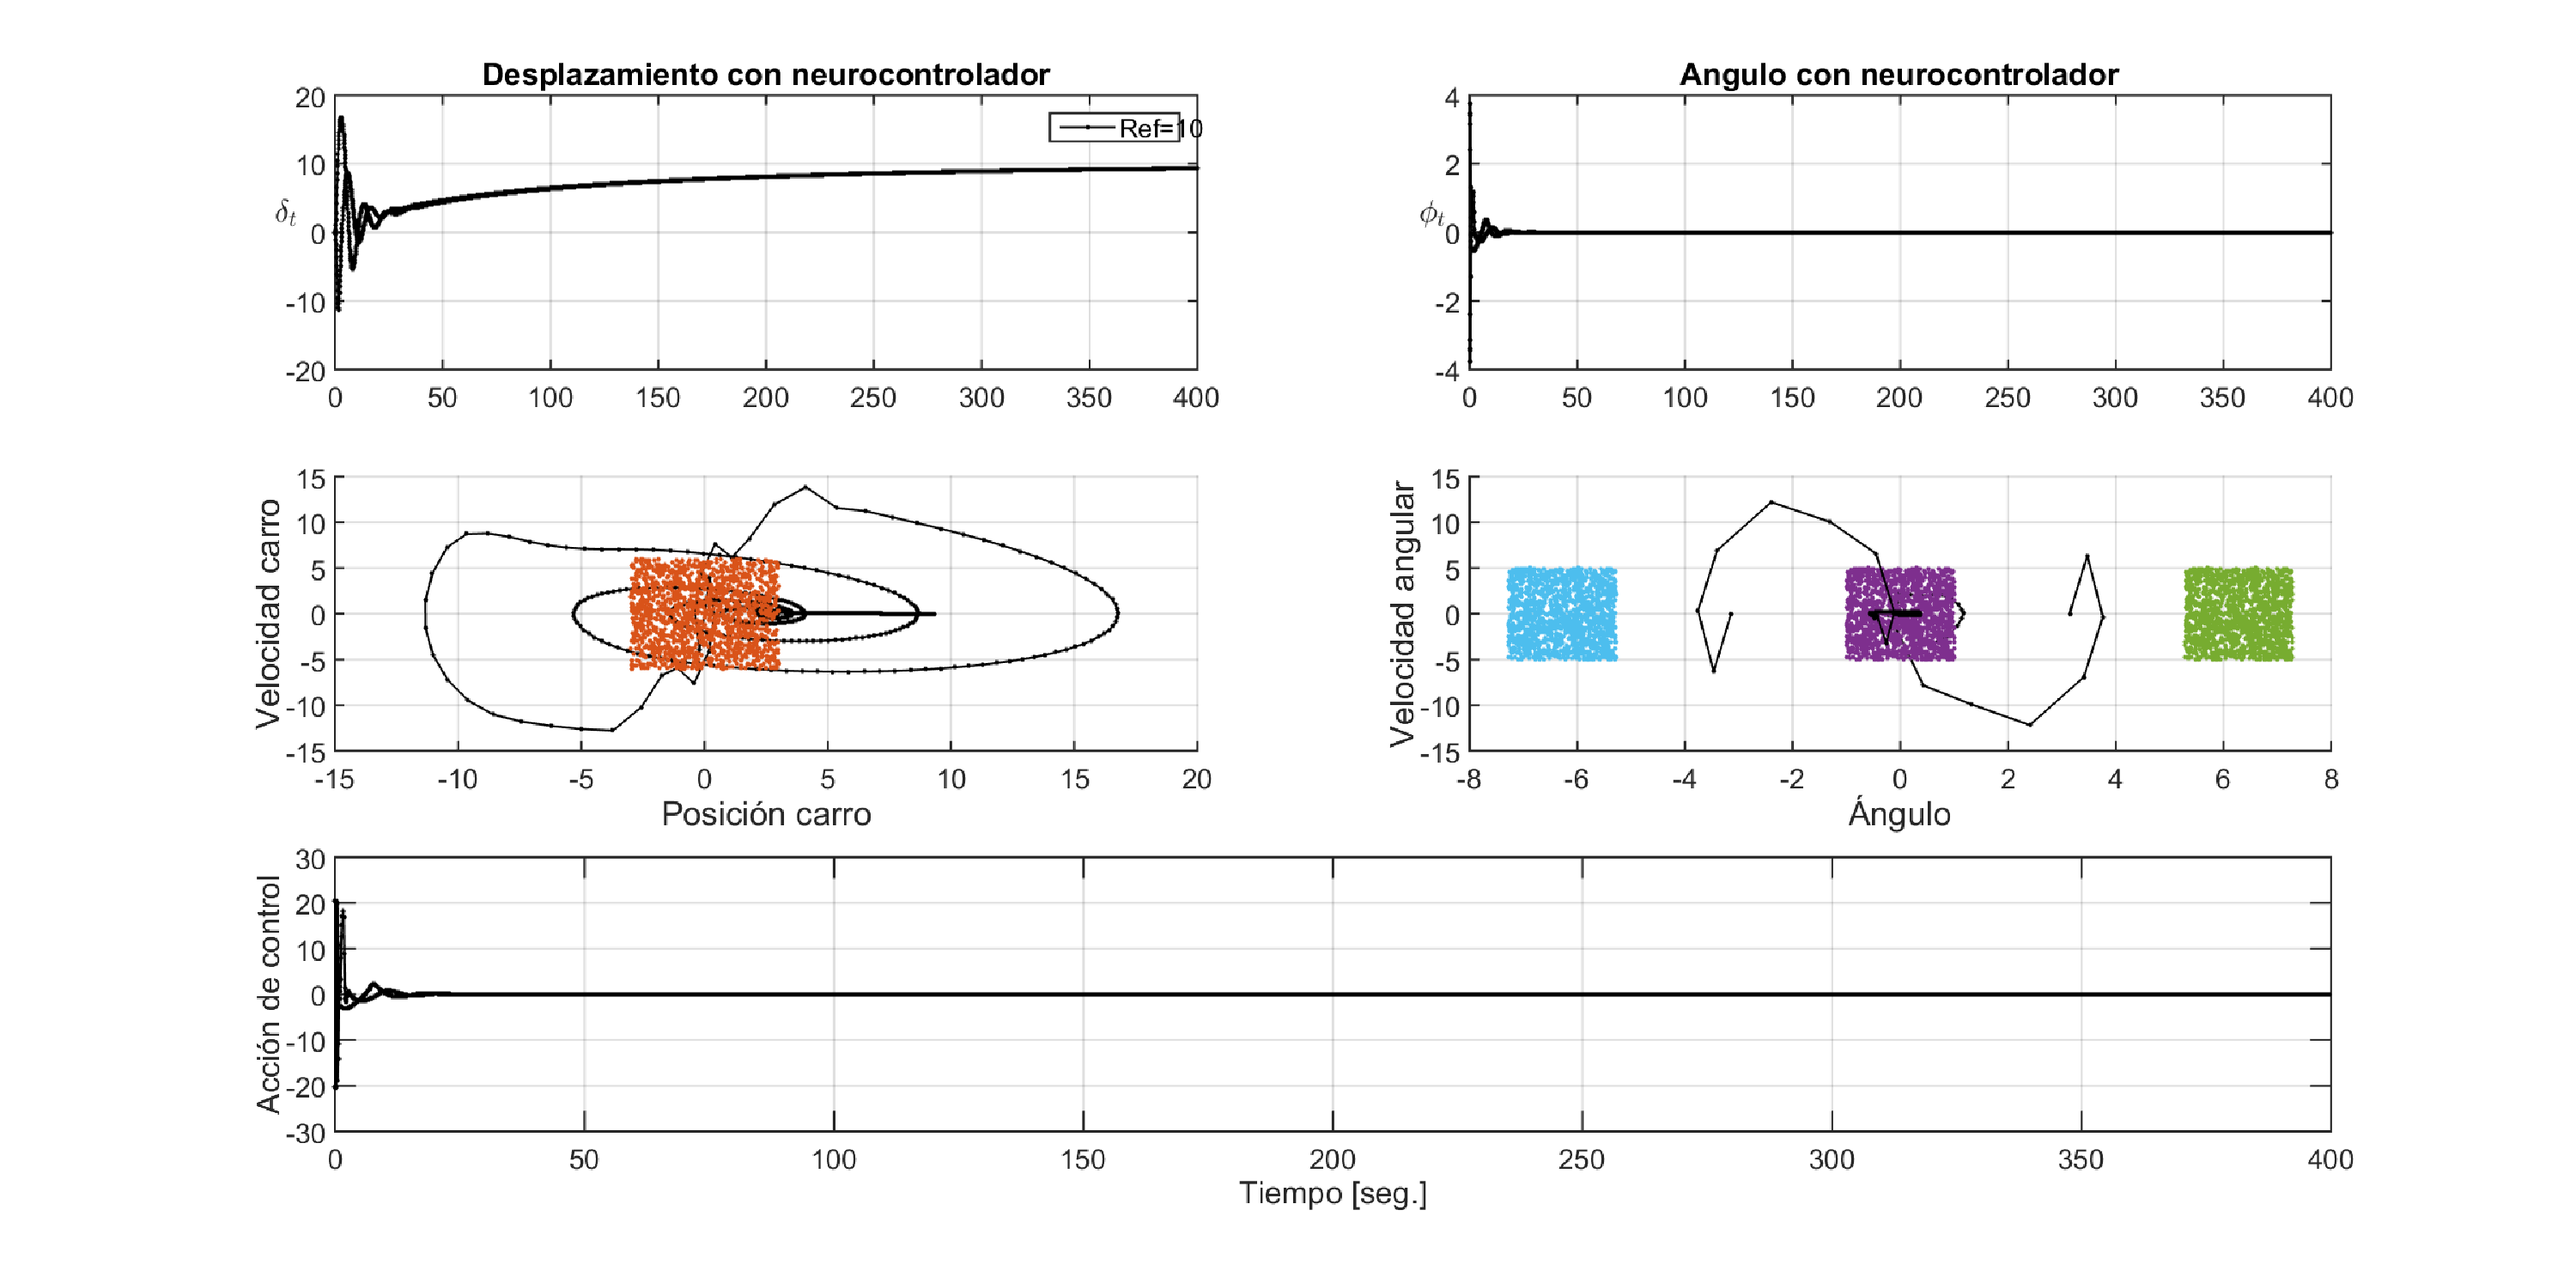

In [ ]:
!apt install megatools

In [ ]:
!megadl 'https://mega.nz/file/21AQSTCT#R0OXPufi3r_xHMmwnXwiPrIlF1KNo9D1hCq28ef3-2o'

Downloaded Pendulo_Japr_Muapr_17.mat


In [ ]:
import scipy.io
#Importa los datos que se generaron desde Octave o Matlab en el archivo .mat
NN_mat = scipy.io.loadmat('/content/Pendulo_Japr_Muapr_17.mat')

In [ ]:
W1a=NN_mat['W1a'] #última columna de W's es el bias
W2a=NN_mat['W2a']
W1=NN_mat['W1']
W2=NN_mat['W2']
Yo_Matlab=NN_mat['Yo']
Ya_Matlab=NN_mat['Ya']
Q11_Matlab=NN_mat['Q11']
Q22_Matlab=NN_mat['Q22']
M_est_Matlab=NN_mat['M_est']
etapas=NN_mat.get('etapas')[0][0]
t_etapa=NN_mat['T0'][0][0]

In [ ]:
def ley_control(sx, W1a, W2a):
    """
    Función de control equivalente a la rutina MATLAB
    Parameters:
    sx: array-like, vector de estado [x1, x2, alfa, x4]
    W1a: array-like, pesos de la primera capa de la red neuronal
    W2a: array-like, pesos de la segunda capa de la red neuronal
    Returns:
    u: señal de control
    """
    # Procesamiento del ángulo alfa (sx[2])
    alfa = sx[2]
    # Normalización del ángulo al rango [-pi, pi]
    if abs(alfa) > np.pi:
        # Reducción módulo 2pi
        while abs(alfa) > 2 * np.pi:
            alfa = np.sign(alfa) * (abs(alfa) - 2 * np.pi)
        # Ajuste al rango [-pi, pi]
        if abs(alfa) > np.pi:
            alfa = np.pi + np.sign(alfa) * (abs(alfa) - np.pi)  # Lo hace positivo
        if abs(alfa) > np.pi:
            alfa = -np.pi + np.sign(alfa) * (abs(alfa) - np.pi)  # Lo hace negativo
    # Actualizar el valor normalizado en el vector de estado
    sx_normalized = sx.copy()
    sx_normalized[2] = alfa
    # Construcción del vector de entrada
    entrada = np.array([sx_normalized[0], sx_normalized[1],
                       sx_normalized[2], sx_normalized[3]])
    X = np.append(entrada, 1)  # Añadir bias
    # Propagación a través de la red neuronal de 2 capas
    s1 = W1a @ X  # Capa oculta
    y11 = np.append(np.tanh(s1), 1)  # Función de activación + bias
    u = W2a @ y11  # Capa de salida
    return u
def j_aproximado(sx, W1, W2): # function y2=j_aproximado(entrada,W1,W2)
    """
    Función costo para ir
    Parameters:
    sx: array-like, vector de estado [x1, x2, alfa, x4]
    W1: array-like, pesos de la primera capa de la red neuronal
    W2: array-like, pesos de la segunda capa de la red neuronal
    Returns:
    y2: costo para ir desde sx hasta el final
    """
    # Procesamiento del ángulo alfa (sx[2])
    alfa = sx[2]
    # Normalización del ángulo al rango [-pi, pi]
    if abs(alfa) > np.pi:
        # Reducción módulo 2pi
        while abs(alfa) > 2 * np.pi:
            alfa = np.sign(alfa) * (abs(alfa) - 2 * np.pi)
        # Ajuste al rango [-pi, pi]
        if abs(alfa) > np.pi:
            alfa = np.pi + np.sign(alfa) * (abs(alfa) - np.pi)  # Lo hace positivo
        if abs(alfa) > np.pi:
            alfa = -np.pi + np.sign(alfa) * (abs(alfa) - np.pi)  # Lo hace negativo
    # Actualizar el valor normalizado en el vector de estado
    sx_normalized = sx.copy()
    sx_normalized[2] = alfa
    # Construcción del vector de entrada
    entrada = np.array([sx_normalized[0], sx_normalized[1],
                       sx_normalized[2], sx_normalized[3]])
    X = np.append(entrada, 1)  # Añadir bias
    # Propagación a través de la red neuronal de 2 capas
    s1 = W1 @ X  # Capa oculta
    y11 = np.append(np.tanh(s1), 1)  # Función de activación + bias
    y2 = W2 @ y11  # Capa de salida
    return y2

In [ ]:
# Evaluate Matlab policy
x_p=np.array([0, 0,-np.pi,0])
costo = np.zeros(etapas)
for k in range(etapas - 1):
    # entrada = np.array([x_p])  # entrada = np.array([[k, x]])
    # entrada = np.append(x_p, 1)
    # consigna = Max_Ya*mlp_a.predict(entrada)[0] #pol_tab_mu1(entrada, M_est, Ya)
    # xj= mod2ve(t_etapa, x_p.reshape(-1, 1), consigna)
    consigna = ley_control(x_p, W1a, W2a)[0]
    xj = mopdm(t_etapa, x_p.reshape(-1, 1), consigna) #regulador a cero
    x_p=xj.flatten()
    costo[k + 1] = costo[k] + indice_g(x_p, consigna)
# costo[etapas - 1] += abs(sal[etapas - 1] - vfinal)
# evoluc[iterac]=costo[etapas - 1]
print(x_p)

[-9.88783552e+00  9.02306813e-03  1.53553818e-03 -7.99425653e-04]


## Variables ajustadas en el algoritmo

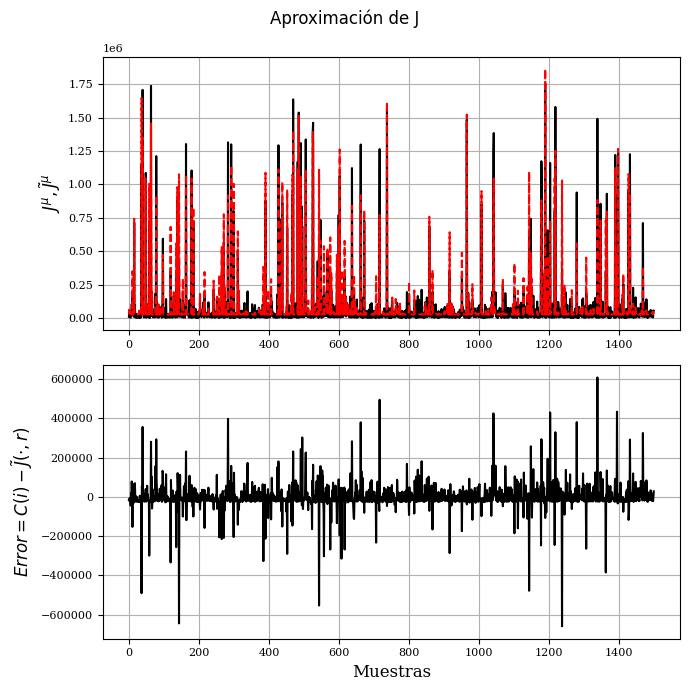

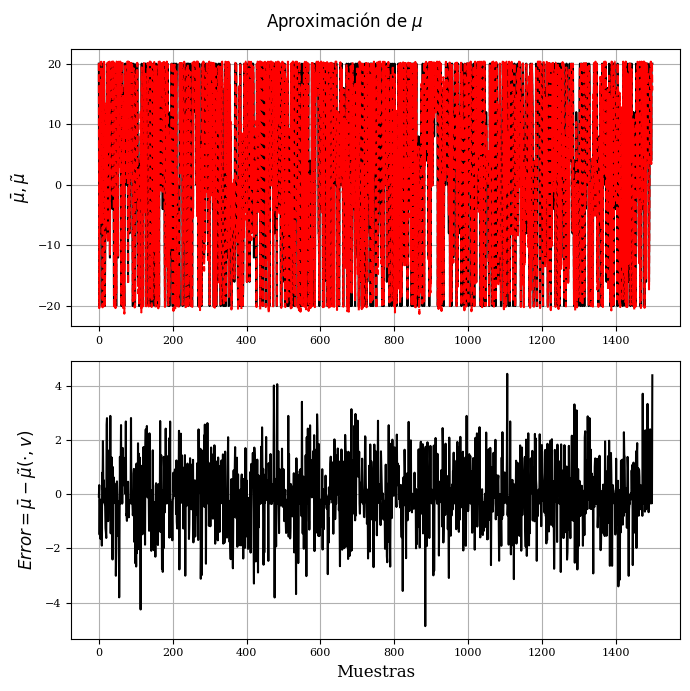

In [ ]:
Yo_ap_=np.zeros(len(Yo_Matlab[0,:]))
for k1 in range(len(Yo_Matlab[0,:])):
  entrada = np.append(M_est_Matlab[:,k1], 1)
  Yo_ap_[k1] = j_aproximado(entrada, W1, W2)[0]
Ya_ap_=np.zeros(len(Ya_Matlab[0,:]))
for k1 in range(len(Ya_Matlab[0,:])):
  entrada = np.append(M_est_Matlab[:,k1], 1)
  Ya_ap_[k1] = ley_control(entrada, W1a, W2a)[0]
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de J')
axs[0].plot(Yo_Matlab[0,:])
axs[0].plot(Yo_ap_)
axs[0].set_ylabel(r'$J^{\mu},\tilde{J}^{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Yo_Matlab[0,:]-Yo_ap_)
axs[1].set_ylabel(r'$Error=C(i)-\tilde{J}(\cdot,r)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()
with plt.style.context('ieee'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Aproximación de $\mu$')
axs[0].plot(Ya_Matlab[0,:])
axs[0].plot(Ya_ap_)
axs[0].set_ylabel(r'$\bar{\mu},\tilde{\mu}$',rotation=90, fontsize=12)
axs[0].grid( True )
axs[1].plot(Ya_Matlab[0,:]-Ya_ap_)
axs[1].set_ylabel(r'$Error=\bar{\mu}-\tilde{\mu}(\cdot,v)$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Muestras',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

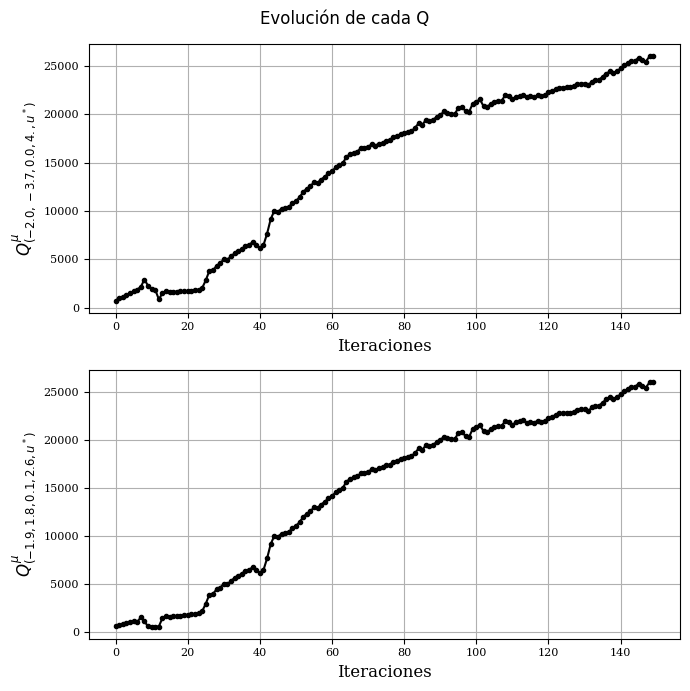

In [ ]:
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,1,figsize=(7,7), dpi= 100)
fig.suptitle(r'Evolución de cada Q')
# M_est(:,10) -2.035175879396985,-3.708542713567840,0.075376884422111,4.095477386934673
# M_est(:,50) -1.974874371859297,1.899497487437186,0.135678391959799,2.638190954773870
axs[0].plot(Q11_Matlab[0,:], '.-')
axs[0].set_ylabel(r'$Q^{\mu}_{(-2.0,-3.7,0.0,4., u^*)}$',rotation=90, fontsize=12)
axs[0].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[0].grid( True )
axs[1].plot(Q22_Matlab[0,:], '.-')
axs[1].set_ylabel(r'$Q^{\mu}_{(-1.9,1.8,0.1,2.6,u^*)}$',rotation=90, fontsize=12)
axs[1].set_xlabel(r'Iteraciones',rotation=0, fontsize=12)
axs[1].grid( True )
plt.tight_layout()
plt.show()

### Evaluación de la ley de control

In [ ]:
etapas1=4000
t_etapa=1e-1;K_M=np.array([-0.0014 ,  -0.1177 ,  -6.9282 ,  -3.2857])
# t_etapa=1e-1; # K_M =      -0.0014   -0.1177   -6.9282   -3.2857
Mat_C=np.array([0., 0., 1., 0.])
u_opt_tab=np.zeros(etapas1)
costo_tab=np.zeros(etapas1)
y_s=np.zeros(etapas1)
x_s=np.zeros((4,etapas1))
t_t=np.zeros(etapas1)
Jc=0; iq=25
# x_1 = 1*M_est[0, iq]
# x_2 = -5*M_est[1, iq]
ve1=0.
ref1=10. #---------------Valor deseado de desplazamiento---------------
xref=np.array([ref1,0,0,0]); KI=4.2442e-04 #%En el LQR daba 4.2442e-06
x_1,x_2,x_3,x_4= [0., 0., np.pi, 0.]
xy =np.array([x_1,x_2,x_3,x_4])
for k in range( etapas1):
  e1=xy[0]-ref1
  ve1=ve1+e1 #Acumula error, PI en TD
  y_s[k]=Mat_C@xy
  x_s[:,k]=xy
  # entrada = np.array([xy])
  # u = Max_Ya*mlp_a.predict(entrada)[0]
  # entrada = np.append(xy, 1)
  u = ley_control(xy-xref, W1a, W2a)[0]+KI*ve1
  # u=ley_control_optimized(entrada, W1a, W2a)[0] #no sirve para distinguir vueltas
  # u = -K_M @ entrada[0] #Controlador lineal
  u_opt_tab[k] = u
  # xj = mod2ve(t_etapa, xy.reshape(-1, 1), u)
  xj = mopdm(t_etapa, xy, u)
  xy=xj.flatten()
  t_t[k]=k*t_etapa
  costo_tab[k] = Jc
  Jc += indice_g( xy, u) # plt.plot(y_s)
print(xy)

[ 9.34270486e+00  3.24979791e-03 -1.76401543e-06  6.10838429e-09]


In [ ]:
M_est=M_est_Matlab.copy()

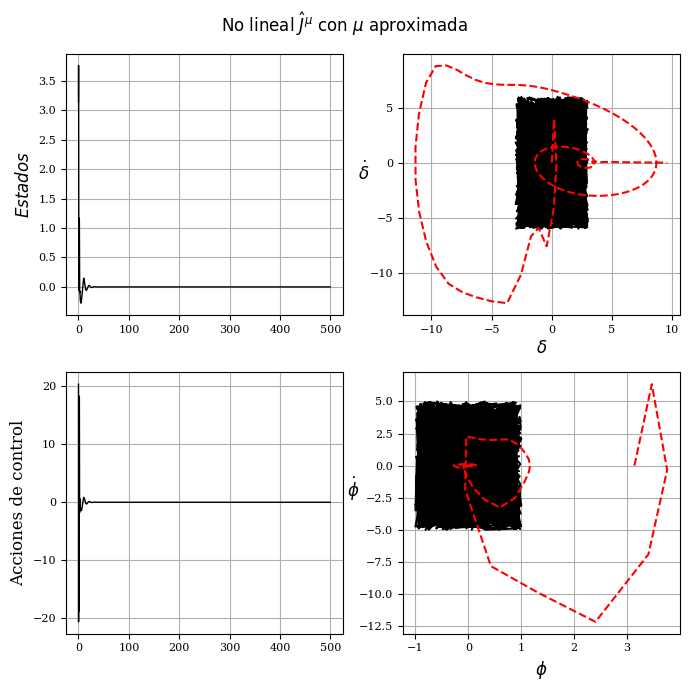

In [ ]:
# Gráficos
with plt.style.context('ieee'):
# with plt.style.context('science'):
# with plt.style.context('dark_background'):
# with plt.style.context('seaborn-v0_8-pastel'):
# with plt.style.context('seaborn-v0_8-poster'):
  fig, axs = plt.subplots(2,2,figsize=(7,7), dpi= 100)
fig.suptitle(r'No lineal $\hat{J}^{\mu}$ con $\mu$ aproximada')
axs[0,0].plot(t_t, y_s.T, linewidth =1.0)
axs[0,0].grid( True )
axs[0,0].set_ylabel(r'$Estados$',rotation=90, fontsize=12)
# axs[0,1].plot(t_t, costo_tab, linewidth =1.0)
# axs[0,1].set_ylabel(r'$Costos$',rotation=90, fontsize=12)
# axs[0,1].grid( True )
axs[1,0].plot(t_t, u_opt_tab, linewidth =1.0)
axs[1,0].set_ylabel(r'Acciones de control',rotation=90, fontsize=12)
axs[1,0].grid( True )
axs[0,1].plot(M_est[0,:], M_est[1,:], markersize=.00001,  marker='.')
axs[0,1].plot(x_s[0,:], x_s[1,:])
axs[0,1].set_ylabel(r'$\dot \delta$',rotation=0, fontsize=12)
axs[0,1].set_xlabel(r'$\delta$',rotation=0, fontsize=12)
axs[0,1].grid( True )
# axs[1,1].semilogy(evoluc, '.-')
axs[1,1].plot(M_est[2,:], M_est[3,:], markersize=.00001,  marker='.')
axs[1,1].plot(x_s[2,:], x_s[3,:])
axs[1,1].set_ylabel(r'$\dot \phi$',rotation=0, fontsize=12)
axs[1,1].set_xlabel(r'$\phi$',rotation=0, fontsize=12)
axs[1,1].grid( True )
plt.tight_layout()
plt.show()

# Conclusiones

Se destaca que la evolución del sistema es afuera del área sombreada, empleada para ajustar la ley de control, por lo que el sistema ha estado empleando extrapolación de la ley de control hallada.
Se cumple el objetivo de control, que consiste en hacer que el péndulo pase de la posición de equilibrio estable, a la posición inestable (vertical) y permaneza alli mientras se desplaza al valor de $\delta_\infty$=10.
Nótese que las acciones de control permanecen acotadas en los valores prefijados.

# Cierre

## Pandoc

In [ ]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic  --fix-missing #funciona ok

In [ ]:
%%shell
apt-get update && apt-get install pandoc -y

In [ ]:
%%shell
pandoc --to pdf --pdf-engine=xelatex  --from ipynb -o '/content/Ejemplos_Control_Extrapolacion.pdf' '/content/Ejemplos_Control_Extrapolacion.ipynb'

[WARNING] Missing character: There is no μ (U+03BC) (U+03BC) in font [lmmono10-regular]:!
[WARNING] Missing character: There is no μ (U+03BC) (U+03BC) in font [lmmono10-regular]:!
[WARNING] Missing character: There is no μ (U+03BC) (U+03BC) in font [lmmono10-regular]:!
[WARNING] Missing character: There is no μ (U+03BC) (U+03BC) in font [lmmono10-regular]:!
[WARNING] Missing character: There is no μ (U+03BC) (U+03BC) in font [lmmono10-regular]:!
